In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import os

import clickhouse_connect

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Make sure wide DataFrames don't wrap
pd.set_option("display.width", None)

# Show the full content of each column (no '...')
pd.set_option("display.max_colwidth", None)

In [2]:
client = clickhouse_connect.get_client(
    host='yaujulxk39.eastus2.azure.clickhouse.cloud',      # or server IP
    port=8443,             # HTTP port (default)
    username='default',
    password='~gZjRLjjOJh1i',
    database='Competitive_Analysis'
)


In [3]:
# ---- Query ----
df_hum_hist = client.query_df("""
    SELECT *
    FROM Competitive_Analysis.DRGHistoricalReviewInformation
    WHERE Client = 'Hum'
""")
df_hum_hist.shape

(76355, 291)

In [4]:
# -------------------------------------------------
# Initial shape of the dataset
# -------------------------------------------------
df_hum = df_hum_hist.copy()

print(df_hum.shape)  

df_hum = df_hum[df_hum['InitialDenialType'] == 'Substantive']
print(df_hum.shape) 

# -------------------------------------------------
# Identify valid Group_Type values
# -------------------------------------------------

group_type_unique = df_hum['Group_Type'].dropna().unique()
print(group_type_unique) 

# -------------------------------------------------
# Filter dataset to only valid Group_Type rows
# Use .copy() to avoid SettingWithCopyWarning
# -------------------------------------------------
df_hum_group_type = df_hum[df_hum['Group_Type'].isin(group_type_unique)].copy()
print(df_hum_group_type.shape) 

# -------------------------------------------------
# Calculate ADRG length
# -------------------------------------------------
df_hum_group_type.loc[:, 'len_adrg'] = (
    df_hum_group_type['ADRG'].astype(str).str.len()
)

print(df_hum_group_type['len_adrg'].value_counts())
print(df_hum_group_type['Group_Type'].value_counts())

# -------------------------------------------------
# Remove invalid DRG / Group_Type combinations
#   1) Group_Type = '01' and ADRG length = 4
#   2) Group_Type = '10' and ADRG length = 3
# -------------------------------------------------
mask_remove = (
    ((df_hum_group_type['Group_Type'] == '01') & (df_hum_group_type['len_adrg'] == 4)) |
    ((df_hum_group_type['Group_Type'] == '10') & (df_hum_group_type['len_adrg'] == 3))
)

df_hum_drg_rem = df_hum_group_type.loc[~mask_remove].copy()
print(df_hum_drg_rem.shape)

# -------------------------------------------------
# Create a copy of InitialDeterminationDate
# -------------------------------------------------
df_hum_drg_rem.loc[:, 'InitialDeterminationDate_copy'] = (
    df_hum_drg_rem['InitialDeterminationDate']
)

print(
    df_hum_drg_rem['Control_ID']
    .value_counts()
    .sort_values(ascending=False)
    .head()
)

# -------------------------------------------------
# Convert date column to datetime
# -------------------------------------------------
df_hum_drg_rem.loc[:, 'InitialDeterminationDate_copy'] = pd.to_datetime(
    df_hum_drg_rem['InitialDeterminationDate_copy'],
    errors='coerce'
)

# -------------------------------------------------
# Keep latest record per Control_ID
# -------------------------------------------------
df_sorted = df_hum_drg_rem.sort_values(
    'InitialDeterminationDate_copy',
    ascending=False
)

df_hum_latest = df_sorted.drop_duplicates(
    subset='Control_ID',
    keep='first'
).copy()

print(df_hum_latest.shape)

# -------------------------------------------------
# Normalize string columns
# -------------------------------------------------
df_hum_latest.loc[:, 'ADRG'] = (
    df_hum_latest['ADRG'].astype(str).str.strip()
)

df_hum_latest.loc[:, 'PRIM_DX'] = (
    df_hum_latest['PRIM_DX'].astype(str).str.strip().str.upper()
)

df_hum_latest.loc[:, 'InitialDeterminationStatus'] = (
    df_hum_latest['InitialDeterminationStatus']
    .astype(str)
    .str.strip()
    .str.upper()
)

# -------------------------------------------------
# Clean numeric fields
# -------------------------------------------------
df_hum_latest.loc[:, 'IDSavings'] = (
    pd.to_numeric(df_hum_latest['IDSavings'], errors='coerce').fillna(0)
)

df_hum_latest.loc[:, 'LOS'] = (
    pd.to_numeric(df_hum_latest['LOS'], errors='coerce').fillna(0)
)

df_hum_latest.loc[:, 'AGE'] = (
    pd.to_numeric(df_hum_latest['AGE'], errors='coerce')
)

# -------------------------------------------------
# Validate AGE values
# -------------------------------------------------
max_age = df_hum_latest['AGE'].max()

df_hum_latest = df_hum_latest[(
    df_hum_latest['AGE'].between(0, max_age))
].copy()
df_hum_latest.loc[:, 'AGE'] = df_hum_latest['AGE'].astype('Int64')
print(df_hum_latest.shape)

# -------------------------------------------------
# Validate LOS values
# -------------------------------------------------
df_hum_latest.loc[:, 'LOS'] = (
    df_hum_latest['LOS'].astype('Int64')
)

df_hum_latest = df_hum_latest[(df_hum_latest['LOS'] >= 0)].copy()
print(df_hum_latest.shape)

# -------------------------------------------------
# Remove extreme savings outliers
# -------------------------------------------------
df_hum_latest = df_hum_latest[
    df_hum_latest['IDSavings'] < 650000
].reset_index(drop=True)

print(df_hum_latest.shape)

# Date only
df_hum_latest['InitialDeterminationDate_date'] = (
    df_hum_latest['InitialDeterminationDate'].dt.date
)

# Year
df_hum_latest['InitialDetermination_Year'] = (
    df_hum_latest['InitialDeterminationDate'].dt.year
)

df_hum_latest["InitialDeterminationDate_date"] = pd.to_datetime(
    df_hum_latest["InitialDeterminationDate_date"],
    errors="coerce"   # handles bad / empty values safely
)


df_hum_latest['InitialDeterminationStatus_Flag'] = (
    df_hum_latest['InitialDeterminationStatus']
    .str.strip()
    .str.upper()
    .map({
        'APPROVED': 0,
        'DENIED': 1
    })
)


df_hum_latest.shape

(76355, 291)
(76355, 291)
<StringArray>
['01', '10']
Length: 2, dtype: string
(76351, 291)
len_adrg
3    75215
4     1136
Name: count, dtype: int64
Group_Type
01    75214
10     1137
Name: count, dtype: Int64
(76340, 292)
Control_ID
HUPTMR-40741    1
HUPTMR-9633     1
HUPTMR-51303    1
HUPTMR-9989     1
HUPTMR-10906    1
Name: count, dtype: Int64
(76340, 293)
(76339, 293)
(76337, 293)
(76337, 293)


(76337, 296)

In [5]:
df_hum_ms_drg = df_hum_latest[df_hum_latest['Group_Type']=='01']
print(df_hum_ms_drg.shape)

df_hum_ms_drg['len_adrg'].value_counts()

(75206, 296)


len_adrg
3    75206
Name: count, dtype: int64

In [6]:
df = df_hum_ms_drg.copy()

adx_cols = [f"A_DX{i}" for i in range(2, 26)]
apx_cols = [f"A_PX{i}" for i in range(1, 26)]
bdx_cols = [f"B_DX{i}" for i in range(2, 26)]
bpx_cols = [f"B_PX{i}" for i in range(1, 26)]

df["A_DX_List"] = df[adx_cols].values.tolist()
df["A_PX_List"] = df[apx_cols].values.tolist()
df["B_DX_List"] = df[bdx_cols].values.tolist()
df["B_PX_List"] = df[bpx_cols].values.tolist()

# Convert to sorted comma separated values
df["A_DX_List"] = df["A_DX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))
df["A_PX_List"] = df["A_PX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))
df["B_DX_List"] = df["B_DX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))
df["B_PX_List"] = df["B_PX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))


def clean_sdx_list(val):
    if pd.isna(val) or val == "":
        return ""
    
    lst = val.split(",")  # split comma-separated values
    cleaned = []
    
    for item in lst:
        item = str(item).upper().strip()       # normalize
        item = item.replace("- MCC", "")       # remove MCC
        item = item.replace("- CC", "")        # remove CC
        item = item.replace("MCC", "")         # safety
        item = item.replace("CC", "")          # safety
        item = item.strip().replace("-", "")   # final cleanup
        cleaned.append(item)
    
    return ",".join(sorted(cleaned))  # sort again and join

df["A_DX_List_Clean"] = df["A_DX_List"].apply(clean_sdx_list)
df["B_DX_List_Clean"] = df["B_DX_List"].apply(clean_sdx_list)

mccandcclist_df = pd.read_excel(r"C:\Arun_MIX\MCCCCList.xlsx")
mccandcclist_df['ICDCode'] = (
    mccandcclist_df['ICDCode']
    .astype(str)
    .str.strip()
    .str.upper()
)
mccandcclist = dict(zip(mccandcclist_df['ICDCode'], mccandcclist_df['MCCorCC']))
print(f"✅ Loaded MCC/CC list with {len(mccandcclist)} entries.")

def map_sdx_types(icd_string, lookup_dict):

    if pd.isna(icd_string) or icd_string == "":
        return []

    icd_list = icd_string.split(",")

    cleaned_list = []
    for code in icd_list:
        code_clean = str(code).strip().upper()
        tag = lookup_dict.get(code_clean, "")
        cleaned_list.append(f"{code_clean} - {tag}")

    return cleaned_list


df['A_DX_Type_list'] = df['A_DX_List_Clean'].apply(lambda x: map_sdx_types(x, mccandcclist))
df['B_DX_Type_list'] = df['B_DX_List_Clean'].apply(lambda x: map_sdx_types(x, mccandcclist))


def split_dx_types(dx_list):

    mcc = [x.split(" - ")[0] for x in dx_list if "- MCC" in x]
    cc = [x.split(" - ")[0] for x in dx_list if "- CC" in x]
    general = [x.split(" - ")[0] for x in dx_list if "- MCC" not in x and "- CC" not in x]

    return pd.Series({
        "A_DX_MCC_Set": ",".join(sorted(mcc)),
        "A_DX_CC_Set": ",".join(sorted(cc)),
        "A_DX_General_Set": ",".join(sorted(general)),
        "A_DX_MCC_Count": len(mcc),
        "A_DX_CC_Count": len(cc),
        "A_DX_General_Count": len(general)
    })


df[[
    "A_DX_MCC_Set",
    "A_DX_CC_Set",
    "A_DX_General_Set",
    "A_DX_MCC_Count",
    "A_DX_CC_Count",
    "A_DX_General_Count"
]] = df["A_DX_Type_list"].apply(split_dx_types)

df.head(1)



✅ Loaded MCC/CC list with 17913 entries.


,Payor,claimid,Client,Control_ID,Claim_Number,PaymentType,Group_Type,Payments,Tax_ID,Provider_ID,HospitalName,LOS,DISP_Code,ADRG,DischargeYear,DischargeMonth,AGE,A_CCCount,A_MCCCount,B_CCCount,B_MCCCount,LOB,MRREQ,MRREC,PRIM_DX,A_DX2,A_DX3,A_DX4,A_DX5,A_DX6,A_DX7,A_DX8,A_DX9,A_DX10,A_DX11,A_DX12,A_DX13,A_DX14,A_DX15,A_DX16,A_DX17,A_DX18,A_DX19,A_DX20,A_DX21,A_DX22,A_DX23,A_DX24,A_DX25,A_POA,A_POA2,A_POA3,A_POA4,A_POA5,A_POA6,A_POA7,A_POA8,A_POA9,A_POA10,A_POA11,A_POA12,A_POA13,A_POA14,A_POA15,A_POA16,A_POA17,A_POA18,A_POA19,A_POA20,A_POA21,A_POA22,A_POA23,A_POA24,A_POA25,A_PX1,A_PX2,A_PX3,A_PX4,A_PX5,A_PX6,A_PX7,A_PX8,A_PX9,A_PX10,A_PX11,A_PX12,A_PX13,A_PX14,A_PX15,A_PX16,A_PX17,A_PX18,A_PX19,A_PX20,A_PX21,A_PX22,A_PX23,A_PX24,A_PX25,B_DISPCode,B_DenialCode,B_DRG,B_PRIMDX,B_DX2,B_DX3,B_DX4,B_DX5,B_DX6,B_DX7,B_DX8,B_DX9,B_DX10,B_DX11,B_DX12,B_DX13,B_DX14,B_DX15,B_DX16,B_DX17,B_DX18,B_DX19,B_DX20,B_DX21,B_DX22,B_DX23,B_DX24,B_DX25,B_POA,B_POA2,B_POA3,B_POA4,B_POA5,B_POA6,B_POA7,B_POA8,B_POA9,B_POA10,B_POA11,B_POA12,B_POA13,B_POA14,B_POA15,B_POA16,B_POA17,B_POA18,B_POA19,B_POA20,B_POA21,B_POA22,B_POA23,B_POA24,B_POA25,B_PX1,B_PX2,B_PX3,B_PX4,B_PX5,B_PX6,B_PX7,B_PX8,B_PX9,B_PX10,B_PX11,B_PX12,B_PX13,B_PX14,B_PX15,B_PX16,B_PX17,B_PX18,B_PX19,B_PX20,B_PX21,B_PX22,B_PX23,B_PX24,B_PX25,A_PRIMDX_Desc,A_DX2_Desc,A_DX3_Desc,A_DX4_Desc,A_DX5_Desc,A_DX6_Desc,A_DX7_Desc,A_DX8_Desc,A_DX9_Desc,A_DX10_Desc,A_DX11_Desc,A_DX12_Desc,A_DX13_Desc,A_DX14_Desc,A_DX15_Desc,A_DX16_Desc,A_DX17_Desc,A_DX18_Desc,A_DX19_Desc,A_DX20_Desc,A_DX21_Desc,A_DX22_Desc,A_DX23_Desc,A_DX24_Desc,A_DX25_Desc,A_PX1_Desc,A_PX2_Desc,A_PX3_Desc,A_PX4_Desc,A_PX5_Desc,A_PX6_Desc,A_PX7_Desc,A_PX8_Desc,A_PX9_Desc,A_PX10_Desc,A_PX11_Desc,A_PX12_Desc,A_PX13_Desc,A_PX14_Desc,A_PX15_Desc,A_PX16_Desc,A_PX17_Desc,A_PX18_Desc,A_PX19_Desc,A_PX20_Desc,A_PX21_Desc,A_PX22_Desc,A_PX23_Desc,A_PX24_Desc,A_PX25_Desc,B_PRIMDX_Desc,B_DX2_Desc,B_DX3_Desc,B_DX4_Desc,B_DX5_Desc,B_DX6_Desc,B_DX7_Desc,B_DX8_Desc,B_DX9_Desc,B_DX10_Desc,B_DX11_Desc,B_DX12_Desc,B_DX13_Desc,B_DX14_Desc,B_DX15_Desc,B_DX16_Desc,B_DX17_Desc,B_DX18_Desc,B_DX19_Desc,B_DX20_Desc,B_DX21_Desc,B_DX22_Desc,B_DX23_Desc,B_DX24_Desc,B_DX25_Desc,B_PX1_Desc,B_PX2_Desc,B_PX3_Desc,B_PX4_Desc,B_PX5_Desc,B_PX6_Desc,B_PX7_Desc,B_PX8_Desc,B_PX9_Desc,B_PX10_Desc,B_PX11_Desc,B_PX12_Desc,B_PX13_Desc,B_PX14_Desc,B_PX15_Desc,B_PX16_Desc,B_PX17_Desc,B_PX18_Desc,B_PX19_Desc,B_PX20_Desc,B_PX21_Desc,B_PX22_Desc,B_PX23_Desc,B_PX24_Desc,B_PX25_Desc,InitialDeterminationDate,InitialDenialType,InitialDeterminationStatus,IDSavings,AdjustedSavings,DXRemoved_AtoB,PRIMDX_DownCoded,InitialCoder,InitialCoder_Employer,InitialCoderID,InitialDoctor,InitialDoctorID,InitialProcessor,InitialProcessorID,len_adrg,InitialDeterminationDate_copy,InitialDeterminationDate_date,InitialDetermination_Year,InitialDeterminationStatus_Flag,A_DX_List,A_PX_List,B_DX_List,B_PX_List,A_DX_List_Clean,B_DX_List_Clean,A_DX_Type_list,B_DX_Type_list,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count
0,Strat,1265742,Hum,HUPTMR-67499,820252450252252,PostPay,01,15464.79,455055149,455055149A,ST ANTHONY SHAWNEE HOSPITAL IN,7,01-ROUTINE/HOME,616,2025,8,52,7,3,7,3,MCD93,2025-11-19,NaT,E11621,G928 - MCC,Z5941,Z5982,Z5986,G9341 - MCC,L97419 - CC,M86171 - CC,M869 - CC,L02611 - CC,E88819,E1140,F3181 - CC,F1511,F1010,E039,I10,B1920,R45851 - CC,Z5900 - CC,E1165,F209,L97519,E1110 - MCC,Z794,Y,Y,<NA>,<NA>,<NA>,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,<NA>,Y,Y,Y,Y,<NA>,0Y6R0Z0,0JBQ0ZZ,0KBV0ZZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,01-ROUTINE/HOME,<NA>,616,E11621,G928 - MCC,Z5941,Z5982,Z5986,G9341 - MCC,L97419 - CC,M86171 - CC,M869 - CC,L02611 - CC,E88819,E1140,F3181 - CC,F1511,F1010,E039,I10,B1920,R45851 - CC,Z5900 - CC,E1165,F209,L97519,E1110 - MCC,Z794,Y,Y,<NA>,<NA>,<NA>,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,<NA>,Y,Y,Y,Y,<NA>,0Y6R0Z0,0JBQ0ZZ,0KBV0ZZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<N

In [7]:
df_with_sdx = df[~(df['A_DX_List'].notna() & (df['A_DX_List'].str.len() == 0))]
print(df_with_sdx.shape)

(73436, 310)


In [8]:
df_with_sdx['InitialDeterminationStatus'].value_counts()

InitialDeterminationStatus
APPROVED    64623
DENIED       8813
Name: count, dtype: Int64

In [9]:
df_with_sdx.head(1)

,Payor,claimid,Client,Control_ID,Claim_Number,PaymentType,Group_Type,Payments,Tax_ID,Provider_ID,HospitalName,LOS,DISP_Code,ADRG,DischargeYear,DischargeMonth,AGE,A_CCCount,A_MCCCount,B_CCCount,B_MCCCount,LOB,MRREQ,MRREC,PRIM_DX,A_DX2,A_DX3,A_DX4,A_DX5,A_DX6,A_DX7,A_DX8,A_DX9,A_DX10,A_DX11,A_DX12,A_DX13,A_DX14,A_DX15,A_DX16,A_DX17,A_DX18,A_DX19,A_DX20,A_DX21,A_DX22,A_DX23,A_DX24,A_DX25,A_POA,A_POA2,A_POA3,A_POA4,A_POA5,A_POA6,A_POA7,A_POA8,A_POA9,A_POA10,A_POA11,A_POA12,A_POA13,A_POA14,A_POA15,A_POA16,A_POA17,A_POA18,A_POA19,A_POA20,A_POA21,A_POA22,A_POA23,A_POA24,A_POA25,A_PX1,A_PX2,A_PX3,A_PX4,A_PX5,A_PX6,A_PX7,A_PX8,A_PX9,A_PX10,A_PX11,A_PX12,A_PX13,A_PX14,A_PX15,A_PX16,A_PX17,A_PX18,A_PX19,A_PX20,A_PX21,A_PX22,A_PX23,A_PX24,A_PX25,B_DISPCode,B_DenialCode,B_DRG,B_PRIMDX,B_DX2,B_DX3,B_DX4,B_DX5,B_DX6,B_DX7,B_DX8,B_DX9,B_DX10,B_DX11,B_DX12,B_DX13,B_DX14,B_DX15,B_DX16,B_DX17,B_DX18,B_DX19,B_DX20,B_DX21,B_DX22,B_DX23,B_DX24,B_DX25,B_POA,B_POA2,B_POA3,B_POA4,B_POA5,B_POA6,B_POA7,B_POA8,B_POA9,B_POA10,B_POA11,B_POA12,B_POA13,B_POA14,B_POA15,B_POA16,B_POA17,B_POA18,B_POA19,B_POA20,B_POA21,B_POA22,B_POA23,B_POA24,B_POA25,B_PX1,B_PX2,B_PX3,B_PX4,B_PX5,B_PX6,B_PX7,B_PX8,B_PX9,B_PX10,B_PX11,B_PX12,B_PX13,B_PX14,B_PX15,B_PX16,B_PX17,B_PX18,B_PX19,B_PX20,B_PX21,B_PX22,B_PX23,B_PX24,B_PX25,A_PRIMDX_Desc,A_DX2_Desc,A_DX3_Desc,A_DX4_Desc,A_DX5_Desc,A_DX6_Desc,A_DX7_Desc,A_DX8_Desc,A_DX9_Desc,A_DX10_Desc,A_DX11_Desc,A_DX12_Desc,A_DX13_Desc,A_DX14_Desc,A_DX15_Desc,A_DX16_Desc,A_DX17_Desc,A_DX18_Desc,A_DX19_Desc,A_DX20_Desc,A_DX21_Desc,A_DX22_Desc,A_DX23_Desc,A_DX24_Desc,A_DX25_Desc,A_PX1_Desc,A_PX2_Desc,A_PX3_Desc,A_PX4_Desc,A_PX5_Desc,A_PX6_Desc,A_PX7_Desc,A_PX8_Desc,A_PX9_Desc,A_PX10_Desc,A_PX11_Desc,A_PX12_Desc,A_PX13_Desc,A_PX14_Desc,A_PX15_Desc,A_PX16_Desc,A_PX17_Desc,A_PX18_Desc,A_PX19_Desc,A_PX20_Desc,A_PX21_Desc,A_PX22_Desc,A_PX23_Desc,A_PX24_Desc,A_PX25_Desc,B_PRIMDX_Desc,B_DX2_Desc,B_DX3_Desc,B_DX4_Desc,B_DX5_Desc,B_DX6_Desc,B_DX7_Desc,B_DX8_Desc,B_DX9_Desc,B_DX10_Desc,B_DX11_Desc,B_DX12_Desc,B_DX13_Desc,B_DX14_Desc,B_DX15_Desc,B_DX16_Desc,B_DX17_Desc,B_DX18_Desc,B_DX19_Desc,B_DX20_Desc,B_DX21_Desc,B_DX22_Desc,B_DX23_Desc,B_DX24_Desc,B_DX25_Desc,B_PX1_Desc,B_PX2_Desc,B_PX3_Desc,B_PX4_Desc,B_PX5_Desc,B_PX6_Desc,B_PX7_Desc,B_PX8_Desc,B_PX9_Desc,B_PX10_Desc,B_PX11_Desc,B_PX12_Desc,B_PX13_Desc,B_PX14_Desc,B_PX15_Desc,B_PX16_Desc,B_PX17_Desc,B_PX18_Desc,B_PX19_Desc,B_PX20_Desc,B_PX21_Desc,B_PX22_Desc,B_PX23_Desc,B_PX24_Desc,B_PX25_Desc,InitialDeterminationDate,InitialDenialType,InitialDeterminationStatus,IDSavings,AdjustedSavings,DXRemoved_AtoB,PRIMDX_DownCoded,InitialCoder,InitialCoder_Employer,InitialCoderID,InitialDoctor,InitialDoctorID,InitialProcessor,InitialProcessorID,len_adrg,InitialDeterminationDate_copy,InitialDeterminationDate_date,InitialDetermination_Year,InitialDeterminationStatus_Flag,A_DX_List,A_PX_List,B_DX_List,B_PX_List,A_DX_List_Clean,B_DX_List_Clean,A_DX_Type_list,B_DX_Type_list,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count
0,Strat,1265742,Hum,HUPTMR-67499,820252450252252,PostPay,01,15464.79,455055149,455055149A,ST ANTHONY SHAWNEE HOSPITAL IN,7,01-ROUTINE/HOME,616,2025,8,52,7,3,7,3,MCD93,2025-11-19,NaT,E11621,G928 - MCC,Z5941,Z5982,Z5986,G9341 - MCC,L97419 - CC,M86171 - CC,M869 - CC,L02611 - CC,E88819,E1140,F3181 - CC,F1511,F1010,E039,I10,B1920,R45851 - CC,Z5900 - CC,E1165,F209,L97519,E1110 - MCC,Z794,Y,Y,<NA>,<NA>,<NA>,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,<NA>,Y,Y,Y,Y,<NA>,0Y6R0Z0,0JBQ0ZZ,0KBV0ZZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,01-ROUTINE/HOME,<NA>,616,E11621,G928 - MCC,Z5941,Z5982,Z5986,G9341 - MCC,L97419 - CC,M86171 - CC,M869 - CC,L02611 - CC,E88819,E1140,F3181 - CC,F1511,F1010,E039,I10,B1920,R45851 - CC,Z5900 - CC,E1165,F209,L97519,E1110 - MCC,Z794,Y,Y,<NA>,<NA>,<NA>,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,<NA>,Y,Y,Y,Y,<NA>,0Y6R0Z0,0JBQ0ZZ,0KBV0ZZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<N

In [10]:
selected_cols = [
    "PaymentType","Payments","AGE",
     "LOS", "ADRG", "PRIM_DX","A_DX_MCC_Set", "A_DX_CC_Set", "A_DX_General_Set","A_DX_MCC_Count",
     "A_DX_CC_Count","A_DX_General_Count",
    "InitialDeterminationStatus"
]

df_new = df_with_sdx[selected_cols].copy()
df_new.shape

(73436, 13)

In [11]:
df_new["Status_binary"] = df_new["InitialDeterminationStatus"].str.strip().str.lower().map({
    "approved": 1,
    "denied": 0
})

df_new.head()

,PaymentType,Payments,AGE,LOS,ADRG,PRIM_DX,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count,InitialDeterminationStatus,Status_binary
0,PostPay,15464.79,52,7,616,E11621,"E1110,G928,G9341","F3181,L02611,L97419,M86171,M869,R45851","B1920,E039,E1140,E1165,E88819,F1010,F1511,F209,I10,L97519,Z5900,Z5941,Z5982,Z5986,Z794",3,6,15,APPROVED,1
1,PostPay,11699.99,85,7,193,J189,"I5033,J9601",E873,"E039,E1165,E785,F0394,F419,I110,K219,K5900,K7469,Z1152,Z66,Z794,Z79890,Z79899,Z87440",2,1,15,APPROVED,1
2,PostPay,15543.60,71,6,377,K921,"J9601,N186","D62,I132,I5032,Z6841","D631,E1122,E6601,E66813,E785,E8351,G4733,I2510,I2720,I4891,J449,Z8673,Z955,Z992",2,4,14,APPROVED,1
4,PostPay,15628.23,67,10,871,A419,"G9341,J189,J690,J9601,R532,R6521","E870,R64","D696,D72819,E119,E7800,E8339,E860,E861,E876,F0280,F79,G20A1,G40909,I959,J9809,N3281,R4182",6,2,16,APPROVED,1
5,PostPay,11594.74,90,4,200,J95811,,"C3412,E440,E871","E1140,E1165,E7800,F17210,J449,N3020,N401,R338,R54,Z6821,Z7984,Z79899,Z8546,Z85828,Z86718,Z87442",0,3,16,APPROVED,1


In [86]:
df = df_new.copy()

In [ ]:
# ============================================================
# 🔰 0️⃣ IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, f1_score
import ast

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# 🔰 1️⃣ LOAD PRETRAINED ICD EMBEDDINGS
# ============================================================
pretrained_embedding = pd.read_json(
    "hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json"
)

def safe_to_dict(x):
    if isinstance(x, dict): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return {}
    return {}

def safe_embedding(emb, dim=512):
    if isinstance(emb, list):
        arr = np.array(emb, dtype=np.float32)
        if arr.shape[0] == dim:
            return arr
    return np.zeros(dim, dtype=np.float32)

def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

pretrained_embedding['metadata'] = pretrained_embedding['metadata'].apply(safe_to_dict)
pretrained_embedding = pretrained_embedding.reset_index(drop=True)
meta_df = pd.json_normalize(pretrained_embedding.pop('metadata'))
pretrained_embedding = pd.concat([pretrained_embedding, meta_df], axis=1)

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))


# ============================================================
# 🔰 2️⃣ CLEAN ICD COLUMNS
# ============================================================
def ensure_list(x):
    if isinstance(x, list): return x
    if pd.isna(x): return []
    return str(x).split(',')

icd_cols = ['A_DX_MCC_Set','A_DX_CC_Set','A_DX_General_Set']


# ============================================================
# 4️⃣ TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['Status_binary'], random_state=42
)

for col in icd_cols:
    train_df[col] = train_df[col].apply(ensure_list)
    train_df[col] = train_df[col].apply(lambda lst: [norm_icd(i) for i in lst if i])

    test_df[col] = test_df[col].apply(ensure_list)
    test_df[col] = test_df[col].apply(lambda lst: [norm_icd(i) for i in lst if i])


# ============================================================
# 🔰 3️⃣ BUILD CO-OCCURRENCE GRAPH
# ============================================================
edges = {}

for _, row in train_df.iterrows():
    icds = list(set(row['A_DX_MCC_Set'] + row['A_DX_CC_Set'] + row['A_DX_General_Set']))

    for a, b in combinations(icds, 2):
        edges[(a, b)] = edges.get((a, b), 0) + 1
        edges[(b, a)] = edges.get((b, a), 0) + 1

node_list = list(set([i for pair in edges.keys() for i in pair]))
node_index = {node:i for i,node in enumerate(node_list)}

edge_index = []
for (a,b), w in edges.items():
    edge_index.append([node_index[a], node_index[b]])

edge_index = np.array(edge_index).T


# ============================================================
# 🔰 4️⃣ NODE FEATURES (PRETRAINED)
# ============================================================
node_features = []
for node in node_list:
    node_features.append(icd_embedding_map.get(node, np.zeros(512)))

node_features = np.array(node_features, dtype=np.float32)


# ============================================================
# 🔰 5️⃣ GAT MODEL
# ============================================================
class GATModel(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.gat1 = GATConv(in_dim, 128, heads=4, dropout=0.3)
        self.gat2 = GATConv(128*4, 64, heads=1, dropout=0.3)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = self.dropout(x)
        x = self.gat2(x, edge_index)
        return F.normalize(x, p=2, dim=1)


# ============================================================
# 🔰 6️⃣ TRAIN GAT
# ============================================================
gat_model = GATModel(node_features.shape[1]).to(device)
optimizer = torch.optim.AdamW(gat_model.parameters(), lr=1e-3)

x = torch.tensor(node_features, dtype=torch.float32).to(device)
edge_index_t = torch.tensor(edge_index, dtype=torch.long).to(device)

for epoch in range(5):
    optimizer.zero_grad()
    out = gat_model(x, edge_index_t)
    loss = out.mean()
    loss.backward()
    optimizer.step()
    print(f"GAT Epoch {epoch+1}, Loss: {loss.item():.4f}")


# ============================================================
# 🔰 7️⃣ GET UPDATED EMBEDDINGS
# ============================================================
gat_model.eval()
with torch.no_grad():
    updated_node_embeddings = gat_model(x, edge_index_t).cpu().numpy()

node_id_to_emb = dict(zip(node_list, updated_node_embeddings))


# ============================================================
# 🔰 8️⃣ ATTENTION POOLING
# ============================================================
attn_vector = torch.randn(updated_node_embeddings.shape[1])

def get_claim_embedding(icd_list):
    embs = [node_id_to_emb[c] for c in icd_list if c in node_id_to_emb]

    if len(embs) == 0:
        return np.zeros(updated_node_embeddings.shape[1])

    embs = torch.tensor(np.array(embs), dtype=torch.float32)
    weights = torch.softmax(torch.matmul(embs, attn_vector), dim=0)
    return torch.sum(weights.unsqueeze(1) * embs, dim=0).numpy()





In [88]:
# ============================================================
# 🔰 9️⃣ ENCODE CATEGORICAL (ADRG, PRIM_DX)
# ============================================================
le_adrg = LabelEncoder()
le_prim = LabelEncoder()

train_df['ADRG_enc'] = le_adrg.fit_transform(train_df['ADRG'].astype(str))
test_df['ADRG_enc'] = le_adrg.transform(test_df['ADRG'].astype(str))

train_df['PRIM_DX_enc'] = le_prim.fit_transform(train_df['PRIM_DX'].astype(str))
test_df['PRIM_DX_enc'] = le_prim.transform(test_df['PRIM_DX'].astype(str))

ValueError: y contains previously unseen labels: '294'

In [ ]:




# ============================================================
# 🔰 🔟 BUILD FEATURES (ICD + TABULAR)
# ============================================================
def build_features(df):
    X = []

    for _, row in df.iterrows():
        icds = row['A_DX_MCC_Set'] + row['A_DX_CC_Set'] + row['A_DX_General_Set']
        emb = get_claim_embedding(icds)

        tabular = np.array([
            row['Payments'],
            row['AGE'],
            row['LOS'],
            row['A_DX_MCC_Count'],
            row['A_DX_CC_Count'],
            row['A_DX_General_Count'],
            row['ADRG_enc'],
            row['PRIM_DX_enc']
        ], dtype=np.float32)

        X.append(np.concatenate([emb, tabular]))

    return np.array(X, dtype=np.float32)


X_train = build_features(train_df)
y_train = train_df['Status_binary'].values

X_test = build_features(test_df)
y_test = test_df['Status_binary'].values


# ============================================================
# 🔰 1️⃣1️⃣ SCALE FEATURES
# ============================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ============================================================
# 🔰 1️⃣2️⃣ MODEL
# ============================================================
class ClaimModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# 🔰 1️⃣3️⃣ FOCAL LOSS
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()


# ============================================================
# 🔰 1️⃣4️⃣ TRAIN MODEL
# ============================================================
model = ClaimModel(X_train.shape[1]).to(device)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

criterion = FocalLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

for epoch in range(15):
    optimizer.zero_grad()
    logits = model(X_train_t).squeeze()
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


# ============================================================
# 🔰 1️⃣5️⃣ EVALUATION
# ============================================================
model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

print("Probs stats:", probs.min(), probs.max(), probs.mean())


In [ ]:
# ============================================================
# 🔰 1️⃣6️⃣ THRESHOLD TUNING
# ============================================================
best_f1 = 0
best_t = 0

for t in np.arange(0.3, 0.7, 0.05):
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best Threshold:", best_t, "Best F1:", best_f1)

preds = (probs > best_t).astype(int)

print(classification_report(y_test, preds))

# GAT 2 - worst

In [85]:
# ============================================================
# 🔰 0️⃣ IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
import ast

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# 🔰 1️⃣ LOAD PRETRAINED ICD EMBEDDINGS
# ============================================================
pretrained_embedding = pd.read_json(
    "hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json"
)

def safe_to_dict(x):
    if isinstance(x, dict): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return {}
    return {}

def safe_embedding(emb, dim=512):
    if isinstance(emb, list):
        arr = np.array(emb, dtype=np.float32)
        if arr.shape[0] == dim:
            return arr
    return np.zeros(dim, dtype=np.float32)

def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

pretrained_embedding['metadata'] = pretrained_embedding['metadata'].apply(safe_to_dict)
pretrained_embedding = pretrained_embedding.reset_index(drop=True)
meta_df = pd.json_normalize(pretrained_embedding.pop('metadata'))
pretrained_embedding = pd.concat([pretrained_embedding, meta_df], axis=1)

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))


# ============================================================
# 🔰 2️⃣ CLEAN ICD LIST COLUMNS
# ============================================================
def ensure_list(x):
    if isinstance(x, list): return x
    if pd.isna(x): return []
    return str(x).split(',')

icd_cols = ['A_DX_MCC_Set','A_DX_CC_Set','A_DX_General_Set']


# ============================================================
# 4️⃣ TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['Status_binary'], random_state=42
)

for col in icd_cols:
    train_df[col] = train_df[col].apply(ensure_list)
    train_df[col] = train_df[col].apply(lambda lst: [norm_icd(i) for i in lst if i])


# ============================================================
# 🔰 3️⃣ BUILD CO-OCCURRENCE GRAPH
# ============================================================
edges = {}

for _, row in train_df.iterrows():
    icds = list(set(row['A_DX_MCC_Set'] + row['A_DX_CC_Set'] + row['A_DX_General_Set']))

    for a, b in combinations(icds, 2):
        edges[(a, b)] = edges.get((a, b), 0) + 1
        edges[(b, a)] = edges.get((b, a), 0) + 1

node_list = list(set([i for pair in edges.keys() for i in pair]))
node_index = {node:i for i,node in enumerate(node_list)}

edge_index = []
for (a,b), w in edges.items():
    edge_index.append([node_index[a], node_index[b]])

edge_index = np.array(edge_index).T


# ============================================================
# 🔰 4️⃣ NODE FEATURES (PRETRAINED EMBEDDINGS)
# ============================================================
node_features = []

for node in node_list:
    node_features.append(icd_embedding_map.get(node, np.zeros(512)))

node_features = np.array(node_features, dtype=np.float32)


# ============================================================
# 🔰 5️⃣ GAT MODEL (FIXED)
# ============================================================
class GATModel(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, out_dim=64, heads=4):
        super().__init__()
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads, dropout=0.3)
        self.gat2 = GATConv(hidden_dim * heads, out_dim, heads=1, dropout=0.3)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = self.dropout(x)
        x = self.gat2(x, edge_index)
        return F.normalize(x, p=2, dim=1)


# ============================================================
# 🔰 6️⃣ TRAIN GAT
# ============================================================
gat_model = GATModel(node_features.shape[1]).to(device)

optimizer = torch.optim.AdamW(gat_model.parameters(), lr=1e-3)

x = torch.tensor(node_features, dtype=torch.float32).to(device)
edge_index_t = torch.tensor(edge_index, dtype=torch.long).to(device)

for epoch in range(5):  # prevent overfit
    gat_model.train()
    optimizer.zero_grad()

    out = gat_model(x, edge_index_t)

    loss = out.mean()  # simple unsupervised loss

    loss.backward()
    optimizer.step()

    print(f"GAT Epoch {epoch+1}, Loss: {loss.item():.4f}")


# ============================================================
# 🔰 7️⃣ GET UPDATED EMBEDDINGS
# ============================================================
gat_model.eval()
with torch.no_grad():
    updated_node_embeddings = gat_model(x, edge_index_t).cpu().numpy()

node_id_to_emb = dict(zip(node_list, updated_node_embeddings))


# ============================================================
# 🔰 8️⃣ ATTENTION POOLING
# ============================================================
attn_vector = torch.randn(updated_node_embeddings.shape[1])

def get_claim_embedding(icd_list):
    embs = []

    for code in icd_list:
        if code in node_id_to_emb:
            embs.append(node_id_to_emb[code])

    if len(embs) == 0:
        return np.zeros(updated_node_embeddings.shape[1])

    embs = np.array(embs, dtype=np.float32)
    embs = torch.from_numpy(embs)

    weights = torch.softmax(torch.matmul(embs, attn_vector), dim=0)
    claim_emb = torch.sum(weights.unsqueeze(1) * embs, dim=0)

    return claim_emb.numpy()


# ============================================================
# 🔰 9️⃣ BUILD FEATURES
# ============================================================
def build_features(df):
    X = []

    for _, row in df.iterrows():
        icds = row['A_DX_MCC_Set'] + row['A_DX_CC_Set'] + row['A_DX_General_Set']
        emb = get_claim_embedding(icds)
        X.append(emb)

    return np.array(X, dtype=np.float32)

X_train = build_features(train_df)
y_train = train_df['Status_binary'].values

X_test = build_features(test_df)
y_test = test_df['Status_binary'].values


# ============================================================
# 🔰 🔟 SCALE FEATURES
# ============================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ============================================================
# 🔰 1️⃣1️⃣ MODEL
# ============================================================
class ClaimModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# 🔰 1️⃣2️⃣ FOCAL LOSS
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()


# ============================================================
# 🔰 1️⃣3️⃣ TRAIN CLAIM MODEL
# ============================================================
model = ClaimModel(X_train.shape[1]).to(device)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

criterion = FocalLoss(alpha=0.75)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

for epoch in range(15):
    model.train()
    optimizer.zero_grad()

    logits = model(X_train_t).squeeze()
    loss = criterion(logits, y_train_t)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


# ============================================================
# 🔰 1️⃣4️⃣ EVALUATION
# ============================================================
model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

print("Probs stats:", probs.min(), probs.max(), probs.mean())


# ============================================================
# 🔰 1️⃣5️⃣ THRESHOLD SEARCH
# ============================================================
best_f1 = 0
best_t = 0

for t in np.arange(0.3, 0.7, 0.05):
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best Threshold:", best_t, "Best F1:", best_f1)

preds = (probs > best_t).astype(int)

print(classification_report(y_test, preds))

GAT Epoch 1, Loss: 0.0102
GAT Epoch 2, Loss: -0.0955
GAT Epoch 3, Loss: -0.1185
GAT Epoch 4, Loss: -0.1228
GAT Epoch 5, Loss: -0.1233
Epoch 1, Loss: 0.1361
Epoch 2, Loss: 0.1290
Epoch 3, Loss: 0.1225
Epoch 4, Loss: 0.1164
Epoch 5, Loss: 0.1108
Epoch 6, Loss: 0.1055
Epoch 7, Loss: 0.1009
Epoch 8, Loss: 0.0969
Epoch 9, Loss: 0.0934
Epoch 10, Loss: 0.0908
Epoch 11, Loss: 0.0884
Epoch 12, Loss: 0.0872
Epoch 13, Loss: 0.0863
Epoch 14, Loss: 0.0863
Epoch 15, Loss: 0.0862
Probs stats: 0.9992021 1.0 0.9992033
Best Threshold: 0.3 Best F1: 0.9361532611451128
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1763
           1       0.88      1.00      0.94     12925

    accuracy                           0.88     14688
   macro avg       0.44      0.50      0.47     14688
weighted avg       0.77      0.88      0.82     14688



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# GAT 1

In [ ]:
# ============================================================
# 🚀 ICD CLAIM PREDICTION PIPELINE (FINAL - GAT + ATTENTION)
# ============================================================

# ============================================================
# 1️⃣ IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import defaultdict
import itertools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from torch_geometric.nn import GATConv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 2️⃣ HELPER FUNCTIONS
# ============================================================

def ensure_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x) or x == "":
        return []
    if isinstance(x, str):
        return [i.strip() for i in x.split(",") if i.strip() != ""]
    return []

def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

def get_all_icds(row):
    return list(set(
        row['A_DX_MCC_Set'] +
        row['A_DX_CC_Set'] +
        row['A_DX_General_Set']
    ))


# ============================================================
# 4️⃣ TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['Status_binary'], random_state=42
)

# ============================================================
# 3️⃣ CLEAN ICD COLUMNS
# ============================================================

icd_cols = ['A_DX_MCC_Set','A_DX_CC_Set','A_DX_General_Set']

for col in icd_cols:
    train_df[col] = train_df[col].apply(ensure_list)
    train_df[col] = train_df[col].apply(lambda lst: [norm_icd(i) for i in lst])

# ============================================================
# 4️⃣ LOAD ICD EMBEDDINGS
# ============================================================

pretrained_embedding = pd.read_json("hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json")

import ast
def safe_to_dict(x):
    if isinstance(x, dict): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return {}
    return {}

def safe_embedding(emb, dim=512):
    if isinstance(emb, list):
        arr = np.array(emb, dtype=np.float32)
        if arr.shape[0] != dim:
            return np.random.normal(0, 0.1, dim)
        return arr
    return np.random.normal(0, 0.1, dim)

pretrained_embedding['metadata'] = pretrained_embedding['metadata'].apply(safe_to_dict)
pretrained_embedding = pretrained_embedding.reset_index(drop=True)
meta_df = pd.json_normalize(pretrained_embedding.pop('metadata'))
pretrained_embedding = pd.concat([pretrained_embedding, meta_df], axis=1)

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))

def get_embedding(icd):
    return icd_embedding_map.get(icd, np.random.normal(0, 0.1, 512))





# ============================================================
# 5️⃣ BUILD CO-OCCURRENCE GRAPH
# ============================================================

cooc = defaultdict(int)

for _, row in train_df.iterrows():
    icds = get_all_icds(row)
    for i, j in itertools.combinations(icds, 2):
        cooc[(i, j)] += 1
        cooc[(j, i)] += 1

# ============================================================
# 6️⃣ ADD HIERARCHY EDGES
# ============================================================

def get_parent(icd):
    return icd[:3]

hierarchy_edges = []
all_icds = set()

for _, row in train_df.iterrows():
    all_icds.update(get_all_icds(row))

for icd in all_icds:
    parent = get_parent(icd)
    hierarchy_edges.append((icd, parent))
    hierarchy_edges.append((parent, icd))

# ============================================================
# 7️⃣ CREATE GRAPH
# ============================================================

nodes = list(set([i for pair in cooc for i in pair] + 
                 [j for pair in cooc for j in pair]))

node2idx = {n:i for i,n in enumerate(nodes)}

edge_index = []

for (i, j), w in cooc.items():
    if w >= 2:
        edge_index.append([node2idx[i], node2idx[j]])

for i, j in hierarchy_edges:
    if i in node2idx and j in node2idx:
        edge_index.append([node2idx[i], node2idx[j]])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous().to(device)

# ============================================================
# 8️⃣ NODE FEATURES
# ============================================================

X_nodes = np.array([get_embedding(n) for n in nodes])
X_nodes = torch.tensor(X_nodes, dtype=torch.float).to(device)

# ============================================================
# 9️⃣ GAT MODEL
# ============================================================

class GAT(torch.nn.Module):
    def __init__(self, in_dim=512, hidden_dim=128):
        super().__init__()
        self.gat1 = GATConv(in_dim, hidden_dim, heads=4, concat=True)
        self.gat2 = GATConv(hidden_dim*4, hidden_dim, heads=1, concat=False)

    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = self.gat2(x, edge_index)
        return x

gat_model = GAT().to(device)
optimizer = torch.optim.Adam(gat_model.parameters(), lr=1e-3)

# ============================================================
# 🔟 TRAIN GAT (SELF-SUPERVISED)
# ============================================================

for epoch in range(15):
    gat_model.train()
    optimizer.zero_grad()

    z = gat_model(X_nodes, edge_index)

    src, dst = edge_index
    pos_score = (z[src] * z[dst]).sum(dim=1)

    loss = -torch.log(torch.sigmoid(pos_score)).mean()

    loss.backward()
    optimizer.step()

    print(f"GAT Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ============================================================
# 1️⃣1️⃣ EXTRACT ICD EMBEDDINGS
# ============================================================

gat_model.eval()
with torch.no_grad():
    final_emb = gat_model(X_nodes, edge_index).cpu().numpy()

gnn_embedding_map = {nodes[i]: final_emb[i] for i in range(len(nodes))}

# ============================================================
# 1️⃣2️⃣ ATTENTION POOLING (CLAIM LEVEL)
# ============================================================

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=0)
        return (weights * x).sum(dim=0)

attn_pool = AttentionPooling(128)

def get_claim_embedding(row):
    icds = get_all_icds(row)
    embs = [gnn_embedding_map[i] for i in icds if i in gnn_embedding_map]

    if len(embs) == 0:
        return np.zeros(128)

    embs = torch.tensor(embs, dtype=torch.float)
    return attn_pool(embs).detach().numpy()

train_df['gnn_emb'] = train_df.apply(get_claim_embedding, axis=1)

# ============================================================
# 1️⃣3️⃣ ADD EXTRA FEATURES
# ============================================================

train_df['MCC_ratio'] = train_df['A_DX_MCC_Count'] / (train_df['A_DX_General_Count'] + 1)
train_df['CC_ratio'] = train_df['A_DX_CC_Count'] / (train_df['A_DX_General_Count'] + 1)

def cooc_strength(row):
    icds = get_all_icds(row)
    score = 0
    for i in range(len(icds)):
        for j in range(i+1, len(icds)):
            score += cooc.get((icds[i], icds[j]), 0)
    return score

train_df['cooc_score'] = train_df.apply(cooc_strength, axis=1)

# ============================================================
# 1️⃣4️⃣ FINAL FEATURE MATRIX
# ============================================================

tabular_cols = ['Payments','AGE','LOS',
                'A_DX_MCC_Count','A_DX_CC_Count','A_DX_General_Count',
                'MCC_ratio','CC_ratio','cooc_score']

X_tab = train_df[tabular_cols].values
X_gnn = np.vstack(train_df['gnn_emb'].values)

X_final = np.hstack([X_tab, X_gnn])
y = train_df['Status_binary'].values

# ============================================================
# 1️⃣5️⃣ TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

# ============================================================
# 1️⃣6️⃣ NORMALIZATION
# ============================================================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# 1️⃣7️⃣ CLAIM MODEL
# ============================================================

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

class ClaimModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()

model = ClaimModel(X_train.shape[1]).to(device)

pos_weight = torch.tensor([(y_train==0).sum()/(y_train==1).sum()]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# 1️⃣8️⃣ TRAIN CLAIM MODEL
# ============================================================

for epoch in range(15):
    model.train()
    optimizer.zero_grad()

    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ============================================================
# 1️⃣9️⃣ EVALUATION
# ============================================================

model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

preds = (probs > 0.45).astype(int)  # tuned threshold

print(classification_report(y_test, preds))

print("Probs stats:", probs.min(), probs.max(), probs.mean())

GAT Epoch 1, Loss: 0.6723
GAT Epoch 2, Loss: 0.5825
GAT Epoch 3, Loss: 0.4327
GAT Epoch 4, Loss: 0.2458
GAT Epoch 5, Loss: 0.0882
GAT Epoch 6, Loss: 0.0167
GAT Epoch 7, Loss: 0.0017
GAT Epoch 8, Loss: 0.0001
GAT Epoch 9, Loss: 0.0000
GAT Epoch 10, Loss: 0.0000
GAT Epoch 11, Loss: -0.0000
GAT Epoch 12, Loss: -0.0000
GAT Epoch 13, Loss: -0.0000
GAT Epoch 14, Loss: -0.0000
GAT Epoch 15, Loss: -0.0000


C:\Users\arunkumara\AppData\Local\Temp\8\ipykernel_23808\435183427.py:229: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  embs = torch.tensor(embs, dtype=torch.float)


Epoch 1, Loss: 0.1731
Epoch 2, Loss: 0.1760
Epoch 3, Loss: 0.1707
Epoch 4, Loss: 0.1682
Epoch 5, Loss: 0.1684
Epoch 6, Loss: 0.1683
Epoch 7, Loss: 0.1676
Epoch 8, Loss: 0.1667
Epoch 9, Loss: 0.1669
Epoch 10, Loss: 0.1666
Epoch 11, Loss: 0.1663
Epoch 12, Loss: 0.1663
Epoch 13, Loss: 0.1663
Epoch 14, Loss: 0.1652
Epoch 15, Loss: 0.1659
              precision    recall  f1-score   support

           0       0.16      0.16      0.16      1410
           1       0.88      0.89      0.89     10340

    accuracy                           0.80     11750
   macro avg       0.52      0.52      0.52     11750
weighted avg       0.80      0.80      0.80     11750

Probs stats: 0.38136387 0.8692312 0.4839214


# getting better

In [57]:
# ============================================================
# 1️⃣ IMPORTS & DEVICE SETUP
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import ast

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 2️⃣ LOAD PRETRAINED ICD EMBEDDINGS
# ============================================================

pretrained_embedding = pd.read_json(
    "hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json"
)

def safe_to_dict(x):
    if isinstance(x, dict): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return {}
    return {}

def safe_embedding(emb, dim=512):
    if isinstance(emb, list):
        arr = np.array(emb, dtype=np.float32)
        if arr.shape[0] == dim:
            return arr
    return np.zeros(dim, dtype=np.float32)

def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

pretrained_embedding['metadata'] = pretrained_embedding['metadata'].apply(safe_to_dict)
pretrained_embedding = pretrained_embedding.reset_index(drop=True)

meta_df = pd.json_normalize(pretrained_embedding.pop('metadata'))
pretrained_embedding = pd.concat([pretrained_embedding, meta_df], axis=1)

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

# ICD → embedding map
icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))

In [58]:
# ============================================================
# 3️⃣ HELPER FUNCTIONS
# ============================================================

def ensure_list(x):
    if isinstance(x, list):
        return x
    
    if pd.isna(x) or x == "":
        return []
    
    # string list
    if isinstance(x, str) and x.startswith('['):
        try:
            return ast.literal_eval(x)
        except:
            return []
    
    # comma separated
    if isinstance(x, str):
        return [i.strip() for i in x.split(',') if i.strip() != ""]
    
    return []

# ============================================================
# 4️⃣ TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['Status_binary'], random_state=42
)

In [59]:
# ============================================================
# 5️⃣ CLEAN ICD COLUMNS
# ============================================================

icd_cols = ['A_DX_MCC_Set','A_DX_CC_Set','A_DX_General_Set']

for col in icd_cols:
    train_df[col] = train_df[col].apply(ensure_list)
    train_df[col] = train_df[col].apply(lambda lst: [norm_icd(i) for i in lst])

In [60]:
train_df.head(1)

,PaymentType,Payments,AGE,LOS,ADRG,PRIM_DX,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count,InitialDeterminationStatus,Status_binary
9819,PostPay,33380.51,65,10,163,I2692,"[J9601, R570]","[D62, J9811, K5190, L7631, L7632]","[D72829, D75829, E1140, E1165, E782, E8720, G8929, I071, I119, I160, I2720, I4510, I959, Z794, Z79891, Z885, Z933]",2,5,17,APPROVED,1


In [61]:
# ============================================================
# 1️⃣ BUILD ICD CO-OCCURRENCE GRAPH
# ============================================================

from collections import defaultdict
import itertools

cooc = defaultdict(int)

def get_all_icds(row):
    return list(set(
        row['A_DX_MCC_Set'] +
        row['A_DX_CC_Set'] +
        row['A_DX_General_Set']
    ))

for _, row in train_df.iterrows():
    icds = get_all_icds(row)
    for i, j in itertools.combinations(icds, 2):
        cooc[(i, j)] += 1
        cooc[(j, i)] += 1

In [62]:
# ============================================================
# 2️⃣ ADD ICD HIERARCHY (CHAPTER → CATEGORY)
# ============================================================

def get_parent(icd):
    return icd[:3]  # category level

hierarchy_edges = []

all_icds = set()
for _, row in train_df.iterrows():
    all_icds.update(get_all_icds(row))

for icd in all_icds:
    parent = get_parent(icd)
    hierarchy_edges.append((icd, parent))
    hierarchy_edges.append((parent, icd))

In [64]:
# ============================================================
# 3️⃣ CREATE GRAPH DATA
# ============================================================

from torch_geometric.data import Data

# Unique nodes
nodes = list(set([i for pair in cooc for i in pair] + 
                 [j for pair in cooc for j in pair]))

node2idx = {n:i for i,n in enumerate(nodes)}

edge_index = []
edge_weight = []

# Co-occurrence edges
for (i, j), w in cooc.items():
    if w >= 2:  # 🔥 threshold to remove noise
        edge_index.append([node2idx[i], node2idx[j]])
        edge_weight.append(w)

# Hierarchy edges
for i, j in hierarchy_edges:
    if i in node2idx and j in node2idx:
        edge_index.append([node2idx[i], node2idx[j]])
        edge_weight.append(1)

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(edge_weight, dtype=torch.float)

In [65]:
# ============================================================
# 4️⃣ NODE FEATURES FROM PRETRAINED EMBEDDINGS
# ============================================================

def get_embedding(icd):
    if icd in icd_embedding_map:
        return icd_embedding_map[icd]
    return np.random.normal(0, 0.1, 512)

X = np.array([get_embedding(n) for n in nodes])
X = torch.tensor(X, dtype=torch.float)

In [66]:
# ============================================================
# 5️⃣ GNN MODEL (GCN)
# ============================================================

from torch_geometric.nn import GCNConv
import torch.nn.functional as F

class ICD_GNN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=128):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

    def forward(self, x, edge_index, edge_weight):
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_weight)
        return x

In [67]:
# ============================================================
# 6️⃣ TRAIN GNN (EDGE RECONSTRUCTION)
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_gnn = ICD_GNN(512).to(device)
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=1e-3)

X = X.to(device)
edge_index = edge_index.to(device)

for epoch in range(20):
    model_gnn.train()
    optimizer.zero_grad()

    z = model_gnn(X, edge_index, edge_weight.to(device))

    # 🔥 dot-product similarity
    src, dst = edge_index
    pos_score = (z[src] * z[dst]).sum(dim=1)

    loss = -torch.log(torch.sigmoid(pos_score)).mean()

    loss.backward()
    optimizer.step()

    print(f"GNN Epoch {epoch+1}, Loss: {loss.item():.4f}")

GNN Epoch 1, Loss: 0.6720
GNN Epoch 2, Loss: 0.6462
GNN Epoch 3, Loss: 0.6091
GNN Epoch 4, Loss: 0.5608
GNN Epoch 5, Loss: 0.5019
GNN Epoch 6, Loss: 0.4350
GNN Epoch 7, Loss: 0.3635
GNN Epoch 8, Loss: 0.2918
GNN Epoch 9, Loss: 0.2250
GNN Epoch 10, Loss: 0.1670
GNN Epoch 11, Loss: 0.1202
GNN Epoch 12, Loss: 0.0847
GNN Epoch 13, Loss: 0.0592
GNN Epoch 14, Loss: 0.0415
GNN Epoch 15, Loss: 0.0296
GNN Epoch 16, Loss: 0.0215
GNN Epoch 17, Loss: 0.0160
GNN Epoch 18, Loss: 0.0122
GNN Epoch 19, Loss: 0.0095
GNN Epoch 20, Loss: 0.0077


In [68]:
# ============================================================
# 7️⃣ FINAL ICD EMBEDDINGS
# ============================================================

model_gnn.eval()
with torch.no_grad():
    final_emb = model_gnn(X, edge_index, edge_weight.to(device)).cpu().numpy()

gnn_embedding_map = {nodes[i]: final_emb[i] for i in range(len(nodes))}

In [69]:
# ============================================================
# 8️⃣ CLAIM LEVEL EMBEDDING
# ============================================================

def get_claim_embedding(row):
    icds = get_all_icds(row)
    embs = [gnn_embedding_map[i] for i in icds if i in gnn_embedding_map]

    if len(embs) == 0:
        return np.zeros(128)

    return np.mean(embs, axis=0)

train_df['gnn_emb'] = train_df.apply(get_claim_embedding, axis=1)

In [70]:
# ============================================================
# 9️⃣ FINAL FEATURE MATRIX
# ============================================================

tabular_cols = ['Payments','AGE','LOS',
                'A_DX_MCC_Count','A_DX_CC_Count','A_DX_General_Count']

X_tab = train_df[tabular_cols].values
X_gnn = np.vstack(train_df['gnn_emb'].values)

X_final = np.hstack([X_tab, X_gnn])

In [72]:
from sklearn.model_selection import train_test_split

y = train_df['Status_binary'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.2,
    stratify=y,   # 🔥 VERY IMPORTANT (keeps class balance)
    random_state=42
)

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [74]:
print("NaNs:", np.isnan(X_train).sum())
print("Shape:", X_train.shape)
print("Sample row:", X_train[0][:10])

NaNs: 0
Shape: (46998, 134)
Sample row: [-0.08171472 -0.56125723 -0.43415744  0.23981834  1.54326452  0.17818519
  2.58793982 -2.58715531 -2.58920162  2.58800903]


In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert to tensor
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

# Model
class ClaimModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()

model = ClaimModel(X_train.shape[1]).to(device)




# 🔥 Handle imbalance
pos_weight = torch.tensor([(y_train==0).sum()/(y_train==1).sum()]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train
for epoch in range(15):
    model.train()
    optimizer.zero_grad()

    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.1667
Epoch 2, Loss: 0.1666
Epoch 3, Loss: 0.1664
Epoch 4, Loss: 0.1662
Epoch 5, Loss: 0.1662
Epoch 6, Loss: 0.1662
Epoch 7, Loss: 0.1660
Epoch 8, Loss: 0.1660
Epoch 9, Loss: 0.1660
Epoch 10, Loss: 0.1659
Epoch 11, Loss: 0.1658
Epoch 12, Loss: 0.1658
Epoch 13, Loss: 0.1658
Epoch 14, Loss: 0.1656
Epoch 15, Loss: 0.1657


In [79]:
from sklearn.metrics import classification_report

model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

# Default threshold
preds = (probs > 0.5).astype(int)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.14      0.42      0.20      1410
           1       0.89      0.64      0.74     10340

    accuracy                           0.61     11750
   macro avg       0.51      0.53      0.47     11750
weighted avg       0.80      0.61      0.68     11750



In [80]:
print("Probs stats:", probs.min(), probs.max(), probs.mean())

Probs stats: 0.4046265 0.66632724 0.5046088


In [77]:
from sklearn.metrics import f1_score

best_t, best_f1 = 0, 0

for t in np.linspace(0.05, 0.5, 20):
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"Best Threshold: {best_t}, F1: {best_f1:.4f}")

Best Threshold: 0.05, F1: 0.9362


# 2nd time

In [29]:
# ============================================================
# 1️⃣ IMPORTS & DEVICE SETUP
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import ast

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [30]:
# ============================================================
# 2️⃣ LOAD PRETRAINED ICD EMBEDDINGS
# ============================================================

pretrained_embedding = pd.read_json(
    "hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json"
)

def safe_to_dict(x):
    if isinstance(x, dict): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return {}
    return {}

def safe_embedding(emb, dim=512):
    if isinstance(emb, list):
        arr = np.array(emb, dtype=np.float32)
        if arr.shape[0] == dim:
            return arr
    return np.zeros(dim, dtype=np.float32)

def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

pretrained_embedding['metadata'] = pretrained_embedding['metadata'].apply(safe_to_dict)
pretrained_embedding = pretrained_embedding.reset_index(drop=True)

meta_df = pd.json_normalize(pretrained_embedding.pop('metadata'))
pretrained_embedding = pd.concat([pretrained_embedding, meta_df], axis=1)

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

# ICD → embedding map
icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))

In [31]:
# ============================================================
# 3️⃣ HELPER FUNCTIONS
# ============================================================

def ensure_list(x):
    if isinstance(x, list):
        return x
    
    if pd.isna(x) or x == "":
        return []
    
    # string list
    if isinstance(x, str) and x.startswith('['):
        try:
            return ast.literal_eval(x)
        except:
            return []
    
    # comma separated
    if isinstance(x, str):
        return [i.strip() for i in x.split(',') if i.strip() != ""]
    
    return []

In [32]:
# ============================================================
# 4️⃣ TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['Status_binary'], random_state=42
)

In [33]:
# ============================================================
# 5️⃣ CLEAN ICD COLUMNS
# ============================================================

icd_cols = ['A_DX_MCC_Set','A_DX_CC_Set','A_DX_General_Set']

for col in icd_cols:
    train_df[col] = train_df[col].apply(ensure_list)
    train_df[col] = train_df[col].apply(lambda lst: [norm_icd(i) for i in lst])

In [34]:
train_df.head(1)

,PaymentType,Payments,AGE,LOS,ADRG,PRIM_DX,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count,InitialDeterminationStatus,Status_binary
9819,PostPay,33380.51,65,10,163,I2692,"[J9601, R570]","[D62, J9811, K5190, L7631, L7632]","[D72829, D75829, E1140, E1165, E782, E8720, G8929, I071, I119, I160, I2720, I4510, I959, Z794, Z79891, Z885, Z933]",2,5,17,APPROVED,1


In [35]:
# ============================================================
# 6️⃣ BUILD ICD LIST
# ============================================================

all_icds = set()

for _, row in train_df.iterrows():
    dx = row['A_DX_MCC_Set'] + row['A_DX_CC_Set'] + row['A_DX_General_Set']
    all_icds.update(dx)

all_icds = sorted(list(all_icds))

if len(all_icds) == 0:
    raise ValueError("No ICD codes found!")

icd_to_idx = {icd: i for i, icd in enumerate(all_icds)}

In [36]:
# ============================================================
# 7️⃣ BUILD CO-OCCURRENCE GRAPH
# ============================================================

co_occurrence = {}

for _, row in train_df.iterrows():
    dx_list = row['A_DX_MCC_Set'] + row['A_DX_CC_Set'] + row['A_DX_General_Set']
    dx_list = [d for d in dx_list if d in icd_to_idx]

    for i in range(len(dx_list)):
        for j in range(i+1, len(dx_list)):
            pair = tuple(sorted([dx_list[i], dx_list[j]]))
            co_occurrence[pair] = co_occurrence.get(pair, 0) + 1

edges, weights = [], []

for (d1, d2), w in co_occurrence.items():
    edges.append([icd_to_idx[d1], icd_to_idx[d2]])
    weights.append(w)

# fallback graph
if len(edges) == 0:
    N = len(all_icds)
    edges = [[i, (i+1)%N] for i in range(N)]
    weights = [1]*N

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(weights, dtype=torch.float32)

In [37]:
# ============================================================
# 8️⃣ NODE FEATURES
# ============================================================

EMB_DIM = 512

def get_embedding(icd):
    emb = icd_embedding_map.get(icd)
    
    if emb is None or np.sum(emb) == 0:
        return np.random.normal(0, 0.01, EMB_DIM).astype(np.float32)
    
    return emb

X = np.stack([get_embedding(icd) for icd in all_icds])
x = torch.tensor(X, dtype=torch.float32)

# Normalize
x = F.normalize(x, p=2, dim=1)

global_graph = Data(
    x=x,
    edge_index=edge_index,
    edge_attr=edge_weight
).to(device)

In [38]:
# ============================================================
# 9️⃣ ICD GNN MODEL
# ============================================================

class ICD_GNN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.conv1 = GCNConv(dim, 256)
        self.conv2 = GCNConv(256, dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, data):
        x = F.relu(self.conv1(data.x, data.edge_index, data.edge_attr))
        x = self.dropout(x)
        x = self.conv2(x, data.edge_index, data.edge_attr)
        return x

In [39]:
# ============================================================
# 🔟 TRAIN ICD GNN
# ============================================================

model_icd = ICD_GNN(EMB_DIM).to(device)
optimizer = torch.optim.Adam(model_icd.parameters(), lr=1e-3)

for epoch in range(10):
    model_icd.train()
    optimizer.zero_grad()

    out = model_icd(global_graph)

    loss = 1 - F.cosine_similarity(out, global_graph.x, dim=1).mean()

    loss.backward()
    optimizer.step()

    print(f"ICD Epoch {epoch+1}, Loss {loss.item():.4f}")

ICD Epoch 1, Loss 0.9916
ICD Epoch 2, Loss 0.8092
ICD Epoch 3, Loss 0.6916
ICD Epoch 4, Loss 0.6189
ICD Epoch 5, Loss 0.5755
ICD Epoch 6, Loss 0.5468
ICD Epoch 7, Loss 0.5283
ICD Epoch 8, Loss 0.5164
ICD Epoch 9, Loss 0.5076
ICD Epoch 10, Loss 0.5016


In [40]:
# ============================================================
# 1️⃣1️⃣ UPDATE ICD EMBEDDINGS
# ============================================================

model_icd.eval()

learned_emb = model_icd(global_graph).detach().cpu().numpy()

icd_embedding_map_updated = {
    icd: learned_emb[idx]
    for icd, idx in icd_to_idx.items()
}

In [41]:
# ============================================================
# 1️⃣2️⃣ CLAIM FEATURE BUILDER
# ============================================================

def build_claim_features(df):
    features = []

    for _, row in df.iterrows():
        dx = (
            ensure_list(row['A_DX_MCC_Set']) +
            ensure_list(row['A_DX_CC_Set']) +
            ensure_list(row['A_DX_General_Set'])
        )

        emb_list = [
            icd_embedding_map_updated.get(d)
            for d in dx if d in icd_embedding_map_updated
        ]

        if len(emb_list) == 0:
            emb = np.zeros(EMB_DIM)
        else:
            emb = np.mean(emb_list, axis=0)

        features.append(emb)

    return np.array(features)

In [42]:
# ============================================================
# 1️⃣3️⃣ BUILD FINAL FEATURES
# ============================================================

X_train_icd = build_claim_features(train_df)
X_test_icd = build_claim_features(test_df)

num_cols = ['Payments','AGE','LOS','A_DX_MCC_Count','A_DX_CC_Count','A_DX_General_Count']

X_train_num = train_df[num_cols].fillna(0).values
X_test_num = test_df[num_cols].fillna(0).values

X_train = np.hstack([X_train_icd, X_train_num])
X_test = np.hstack([X_test_icd, X_test_num])

y_train = train_df['Status_binary'].values
y_test = test_df['Status_binary'].values

In [45]:
# ============================================================
# 🔥 FIX: CONVERT TO PURE NUMERIC MATRIX
# ============================================================

# Convert to float safely
X_train = np.array(X_train, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)

y_train = np.array(y_train, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

In [46]:
# ============================================================
# 1️⃣4️⃣ CLAIM MODEL
# ============================================================

class ClaimModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# 1

In [47]:
# ============================================================
# 1️⃣5️⃣ TRAIN CLAIM MODEL
# ============================================================

model = ClaimModel(X_train.shape[1]).to(device)

pos_weight = torch.tensor([(y_train==0).sum()/(y_train==1).sum()]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

for epoch in range(10):
    model.train()
    optimizer.zero_grad()

    logits = model(X_train_t).squeeze()
    loss = criterion(logits, y_train_t)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 11.9492
Epoch 2, Loss: 4.5970
Epoch 3, Loss: 2.4777
Epoch 4, Loss: 4.4309
Epoch 5, Loss: 3.9847
Epoch 6, Loss: 2.0906
Epoch 7, Loss: 0.8396
Epoch 8, Loss: 1.9153
Epoch 9, Loss: 1.5126
Epoch 10, Loss: 0.1752


In [49]:
# ============================================================
# 1️⃣6️⃣ EVALUATION
# ============================================================

model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    logits = model(X_test_t).squeeze()
    probs = torch.sigmoid(logits).cpu().numpy()

# Lower threshold (important)
preds = (probs > 0.5).astype(int)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      1763
         1.0       0.88      1.00      0.94     12925

    accuracy                           0.88     14688
   macro avg       0.44      0.50      0.47     14688
weighted avg       0.77      0.88      0.82     14688



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# 2

In [50]:
# ============================================================
# 1️⃣5️⃣ TRAIN CLAIM MODEL (IMBALANCE FIXED + STRONG MODEL)
# ============================================================

# 🔥 Flip labels (IMPORTANT)
y_train = 1 - y_train
y_test = 1 - y_test

# Convert to numpy float32
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

# Convert to torch
X_train_t = torch.from_numpy(X_train).to(device)
y_train_t = torch.from_numpy(y_train).to(device)

# 🔥 Better Model
class ClaimModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()

model = ClaimModel(X_train.shape[1]).to(device)

# 🔥 FOCAL LOSS (BEST FOR IMBALANCE)
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        loss = self.alpha * (1 - pt)**self.gamma * bce
        return loss.mean()

criterion = FocalLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 🔥 Training loop
for epoch in range(15):
    model.train()
    optimizer.zero_grad()

    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 11.6906
Epoch 2, Loss: 16.9746
Epoch 3, Loss: 6.9984
Epoch 4, Loss: 10.0721
Epoch 5, Loss: 11.5652
Epoch 6, Loss: 11.3117
Epoch 7, Loss: 10.0679
Epoch 8, Loss: 8.1109
Epoch 9, Loss: 6.1618
Epoch 10, Loss: 5.4512
Epoch 11, Loss: 7.2293
Epoch 12, Loss: 7.3653
Epoch 13, Loss: 5.4823
Epoch 14, Loss: 4.6672
Epoch 15, Loss: 5.1037


In [53]:
from sklearn.metrics import f1_score

best_t, best_f1 = 0, 0

for t in np.linspace(0.05, 0.5, 20):
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nBest Threshold: {best_t}, Best F1: {best_f1:.4f}")


Best Threshold: 0, Best F1: 0.0000


In [54]:
print("Prediction probability stats:")
print("Min:", probs.min())
print("Max:", probs.max())
print("Mean:", probs.mean())

Prediction probability stats:
Min: 0.0
Max: 0.13416141
Mean: 4.494071e-05


In [51]:
# ============================================================
# 1️⃣6️⃣ EVALUATION (FIXED)
# ============================================================

model.eval()

X_test_t = torch.from_numpy(X_test).to(device)

with torch.no_grad():
    logits = model(X_test_t)
    probs = torch.sigmoid(logits).cpu().numpy()

# 🔥 Try multiple thresholds
for t in [0.1, 0.15, 0.2, 0.25, 0.3]:
    preds = (probs > t).astype(int)
    
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, preds))


Threshold = 0.1
              precision    recall  f1-score   support

         0.0       0.88      1.00      0.94     12925
         1.0       0.00      0.00      0.00      1763

    accuracy                           0.88     14688
   macro avg       0.44      0.50      0.47     14688
weighted avg       0.77      0.88      0.82     14688


Threshold = 0.15
              precision    recall  f1-score   support

         0.0       0.88      1.00      0.94     12925
         1.0       0.00      0.00      0.00      1763

    accuracy                           0.88     14688
   macro avg       0.44      0.50      0.47     14688
weighted avg       0.77      0.88      0.82     14688


Threshold = 0.2
              precision    recall  f1-score   support

         0.0       0.88      1.00      0.94     12925
         1.0       0.00      0.00      0.00      1763

    accuracy                           0.88     14688
   macro avg       0.44      0.50      0.47     14688
weighted avg       0.7

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packag

In [52]:
from sklearn.metrics import f1_score

best_t, best_f1 = 0, 0

for t in np.linspace(0.05, 0.5, 20):
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nBest Threshold: {best_t}, Best F1: {best_f1:.4f}")


Best Threshold: 0, Best F1: 0.0000


# ICD-based claim denial prediction using GNN + hierarchy + co-occurrence + imbalance handling.

In [22]:
# ============================================================
# 1️⃣ LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# 2️⃣ LOAD ICD EMBEDDINGS
# ============================================================
# Load pretrained ICD-10 embeddings
pretrained_embedding = pd.read_json("hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json")

import ast
def safe_to_dict(x):
    if isinstance(x, dict): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return {}
    return {}

def safe_embedding(emb, dim=512):
    # Ensure valid 512-dim vector
    if isinstance(emb, list):
        arr = np.array(emb, dtype=np.float32)
        if arr.shape[0] != dim:
            return np.zeros(dim, dtype=np.float32)
        return arr
    return np.zeros(dim, dtype=np.float32)

# Normalize ICD code strings
def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

pretrained_embedding['metadata'] = pretrained_embedding['metadata'].apply(safe_to_dict)
pretrained_embedding = pretrained_embedding.reset_index(drop=True)
meta_df = pd.json_normalize(pretrained_embedding.pop('metadata'))
pretrained_embedding = pd.concat([pretrained_embedding, meta_df], axis=1)

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

# Map ICD → embedding
icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))

# ============================================================
# 3️⃣ LOAD CLAIMS DATA
# ============================================================
# Your dataset should have these columns:
# PaymentType, Payments, AGE, LOS, ADRG, PRIM_DX,
# A_DX_MCC_Set, A_DX_CC_Set, A_DX_General_Set,
# A_DX_MCC_Count, A_DX_CC_Count, A_DX_General_Count,
# InitialDeterminationStatus, Status_binary

claims_df = df_new.copy()  # Update path

# Train/test split
train_df, test_df = train_test_split(claims_df, test_size=0.2, stratify=claims_df['Status_binary'], random_state=42)

# ============================================================
# 4️⃣ ICD CO-OCCURRENCE GRAPH
# ============================================================
# Create a mapping ICD → index
all_icds = sorted(set().union(*train_df['A_DX_MCC_Set'].fillna('').tolist(),
                             *train_df['A_DX_CC_Set'].fillna('').tolist(),
                             *train_df['A_DX_General_Set'].fillna('').tolist()))
icd_to_idx = {icd: idx for idx, icd in enumerate(all_icds)}

# Build co-occurrence edges
co_occurrence = {}
for idx, row in train_df.iterrows():
    dx_list = row['A_DX_MCC_Set'] + row['A_DX_CC_Set'] + row['A_DX_General_Set']
    for i, dx1 in enumerate(dx_list):
        for dx2 in dx_list[i+1:]:
            key = tuple(sorted([dx1, dx2]))
            co_occurrence[key] = co_occurrence.get(key, 0) + 1

edges = []
for (dx1, dx2), w in co_occurrence.items():
    if dx1 in icd_to_idx and dx2 in icd_to_idx:
        edges.append([icd_to_idx[dx1], icd_to_idx[dx2]])

edges = np.array(edges, dtype=np.int64)
if edges.shape[0] == 0:
    # fallback: fully connected
    N = len(all_icds)
    edges = np.array([[i, j] for i in range(N) for j in range(N) if i != j], dtype=np.int64)

edge_index = torch.tensor(edges.T, dtype=torch.long)

# Node features
x = torch.tensor([icd_embedding_map.get(icd, np.zeros(512)) for icd in all_icds], dtype=torch.float32)

global_graph = Data(x=x, edge_index=edge_index).to(device)

# ============================================================
# 5️⃣ ICD GNN MODEL
# ============================================================
class ICD_GNN(nn.Module):
    def __init__(self, emb_dim=512):
        super().__init__()
        self.conv1 = GCNConv(emb_dim, 256)
        self.conv2 = GCNConv(256, emb_dim)

    def forward(self, data):
        x = F.relu(self.conv1(data.x, data.edge_index))
        x = self.conv2(x, data.edge_index)
        return x

model_icd = ICD_GNN().to(device)
optimizer = torch.optim.Adam(model_icd.parameters(), lr=1e-3)

# ============================================================
# 6️⃣ TRAIN ICD GNN
# ============================================================
for epoch in range(5):
    model_icd.train()
    optimizer.zero_grad()
    out = model_icd(global_graph)
    loss = ((out - global_graph.x)**2).mean()  # MSE to original embeddings
    loss.backward()
    optimizer.step()
    print(f"ICD GNN Epoch {epoch+1}, Loss {loss.item():.4f}")

# Updated ICD embeddings
learned_emb = model_icd(global_graph).detach().cpu().numpy()
icd_embedding_map_updated = {icd: learned_emb[idx] for icd, idx in icd_to_idx.items()}

# ============================================================
# 7️⃣ CLAIM DATASET WITH EMBEDDINGS
# ============================================================
class ClaimDataset(Dataset):
    def __init__(self, df):
        self.df = df
        self.num_features = ['Payments', 'AGE', 'LOS',
                             'A_DX_MCC_Count', 'A_DX_CC_Count', 'A_DX_General_Count']
        self.cat_features = ['PaymentType', 'ADRG']
        self.y = torch.tensor(df['Status_binary'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Numeric
        numeric = torch.tensor([row[f] for f in self.num_features], dtype=torch.float32)
        # Categorical embeddings (convert to index)
        cat_emb = []
        for c in self.cat_features:
            val = str(row[c])
            emb = icd_embedding_map_updated.get(val, np.zeros(512))
            cat_emb.append(torch.tensor(emb, dtype=torch.float32))
        cat_emb = torch.cat(cat_emb, dim=0)
        # ICD embeddings
        icd_list = row['A_DX_MCC_Set'] + row['A_DX_CC_Set'] + row['A_DX_General_Set']
        icd_embs = [torch.tensor(icd_embedding_map_updated.get(dx, np.zeros(512)), dtype=torch.float32) for dx in icd_list]
        if len(icd_embs) == 0:
            icd_embs = [torch.zeros(512)]
        icd_emb = torch.mean(torch.stack(icd_embs), dim=0)  # average pooling

        # Final feature vector
        features = torch.cat([numeric, cat_emb, icd_emb], dim=0)
        y = torch.tensor(row['Status_binary'], dtype=torch.float32)
        return features, y

# DataLoaders
train_ds = ClaimDataset(train_df)
test_ds  = ClaimDataset(test_df)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

# ============================================================
# 8️⃣ CLAIM CLASSIFIER MODEL
# ============================================================
class ClaimGNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.out(x).squeeze(1)

# Compute input dimension dynamically
sample_features, _ = train_ds[0]
input_dim = sample_features.shape[0]
model_claim = ClaimGNN(input_dim).to(device)

optimizer_claim = torch.optim.Adam(model_claim.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

# ============================================================
# 9️⃣ TRAIN CLAIM CLASSIFIER
# ============================================================
for epoch in range(10):
    model_claim.train()
    total_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer_claim.zero_grad()
        logits = model_claim(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer_claim.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

# ============================================================
# 10️⃣ EVALUATE
# ============================================================
from sklearn.metrics import classification_report

model_claim.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        logits = model_claim(X)
        pred = torch.sigmoid(logits) > 0.5
        y_true.extend(y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

print(classification_report(y_true, y_pred))

ICD GNN Epoch 1, Loss 0.0000
ICD GNN Epoch 2, Loss 0.0000
ICD GNN Epoch 3, Loss 0.0000
ICD GNN Epoch 4, Loss 0.0000
ICD GNN Epoch 5, Loss 0.0000
Epoch 1, Loss: 0.4778
Epoch 2, Loss: 0.3802
Epoch 3, Loss: 0.3734
Epoch 4, Loss: 0.3709
Epoch 5, Loss: 0.3687
Epoch 6, Loss: 0.3672
Epoch 7, Loss: 0.3670
Epoch 8, Loss: 0.3672
Epoch 9, Loss: 0.3666
Epoch 10, Loss: 0.3669
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      1763
         1.0       0.88      1.00      0.94     12925

    accuracy                           0.88     14688
   macro avg       0.44      0.50      0.47     14688
weighted avg       0.77      0.88      0.82     14688



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# prev

In [13]:
import ast

# ============================================================
# LOAD DATA
# ============================================================

pretrained_embedding = pd.read_json(
    "hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json"
)

# ============================================================
# SAFE PARSERS
# ============================================================

def safe_to_dict(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return {}
    return {}

def parse_embedding(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return None
    return None

# ============================================================
# NORMALIZE METADATA
# ============================================================

pretrained_embedding["metadata"] = pretrained_embedding["metadata"].apply(safe_to_dict)

pretrained_embedding = pretrained_embedding.reset_index(drop=True)

meta_df = pd.json_normalize(pretrained_embedding.pop("metadata"))

pretrained_embedding = pd.concat([pretrained_embedding, meta_df], axis=1)

# ============================================================
# NORMALIZE ICD CODES
# ============================================================

def norm_icd(x):
    return str(x).upper().replace(".", "").strip()

pretrained_embedding["id"] = pretrained_embedding["id"].astype(str).apply(norm_icd)

# ============================================================
# PARSE EMBEDDINGS
# ============================================================

pretrained_embedding["embedding"] = pretrained_embedding["embedding"].apply(parse_embedding)

# ============================================================
# VALIDATE EMBEDDINGS (STRICT)
# ============================================================

EMB_DIM = 512

def validate_embedding(emb):

    if emb is None:
        return None

    arr = np.asarray(emb, dtype="float32")

    if arr.ndim != 1 or arr.shape[0] != EMB_DIM:
        return None

    return arr

pretrained_embedding["embedding"] = pretrained_embedding["embedding"].apply(validate_embedding)

# ============================================================
# REMOVE INVALID ROWS (IMPORTANT)
# ============================================================

before = len(pretrained_embedding)

pretrained_embedding = pretrained_embedding.dropna(subset=["embedding"])

after = len(pretrained_embedding)

print(f"Removed {before - after} invalid embeddings")

# ============================================================
# REMOVE DUPLICATES (KEEP FIRST)
# ============================================================

pretrained_embedding = pretrained_embedding.drop_duplicates(subset=["id"])

# ============================================================
# CREATE MATRIX + MAP
# ============================================================

X_emb_512 = np.vstack(pretrained_embedding["embedding"].values)

icd_embedding_map = dict(
    zip(pretrained_embedding["id"], pretrained_embedding["embedding"])
)

print("Final shape:", X_emb_512.shape)
print("Unique ICD codes:", len(icd_embedding_map))

Removed 0 invalid embeddings
Final shape: (74044, 512)
Unique ICD codes: 74044


In [14]:
def get_prefixes(icd):
    return [
        icd[:3],  # Category level (E11)
        icd[:1]   # Chapter level (E)
    ]

In [15]:
from collections import defaultdict

prefix_map = defaultdict(list)

for icd, emb in icd_embedding_map.items():

    for prefix in get_prefixes(icd):
        prefix_map[prefix].append(emb)

# Average embeddings
prefix_embedding_map = {
    k: np.mean(v, axis=0)
    for k, v in prefix_map.items()
}

In [16]:
def get_icd_embedding(icd, emb_dim=512):

    icd = str(icd).upper().replace('.', '').strip()

    # 1️⃣ Exact match
    if icd in icd_embedding_map:
        return icd_embedding_map[icd]

    # 2️⃣ Category fallback (E11)
    if icd[:3] in prefix_embedding_map:
        return prefix_embedding_map[icd[:3]]

    # 3️⃣ Chapter fallback (E)
    if icd[:1] in prefix_embedding_map:
        return prefix_embedding_map[icd[:1]]

    # 4️⃣ Unknown fallback
    return np.zeros(emb_dim, dtype="float32")

In [17]:
def extract_hierarchy(icd):

    icd = str(icd).upper().replace('.', '').strip()

    return {
        "chapter": icd[:1],
        "category": icd[:3],
        "full": icd
    }

In [18]:
def get_hierarchy_embedding(icd, emb_dim=512):

    parts = extract_hierarchy(icd)

    emb_list = []

    # Full code
    emb_list.append(get_icd_embedding(parts["full"], emb_dim))

    # Category
    if parts["category"] in prefix_embedding_map:
        emb_list.append(prefix_embedding_map[parts["category"]])

    # Chapter
    if parts["chapter"] in prefix_embedding_map:
        emb_list.append(prefix_embedding_map[parts["chapter"]])

    # Combine (mean pooling)
    return np.mean(emb_list, axis=0)

In [19]:
def convert_dx_list(dx_list):

    if len(dx_list) == 0:
        return []

    return [get_hierarchy_embedding(dx) for dx in dx_list]

In [20]:
df["PRIM_DX_emb"] = df["PRIM_DX"].apply(lambda x: get_hierarchy_embedding(x))

df["MCC_Set_embeddings"] = df["A_DX_MCC_Set"].apply(convert_dx_list)
df["CC_Set_embeddings"] = df["A_DX_CC_Set"].apply(convert_dx_list)
df["SDX_Set_embeddings"] = df["A_DX_General_Set"].apply(convert_dx_list)

KeyboardInterrupt: 

# 20260316

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
pretrained_embedding = pd.read_json("hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json")
def safe_to_dict(x):
    if isinstance(x, dict): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return {}
    return {}

def safe_embedding(x):
    if isinstance(x, list): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return None
    return None

pretrained_embedding['metadata'] = pretrained_embedding['metadata'].apply(safe_to_dict)
pretrained_embedding = pretrained_embedding.reset_index(drop=True)
meta_df = pd.json_normalize(pretrained_embedding.pop('metadata'))
pretrained_embedding = pd.concat([pretrained_embedding, meta_df], axis=1)

def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

In [ ]:
# --------------------------------------------------
# 1. Ensure embeddings are valid 512-d vectors
# --------------------------------------------------
def safe_embedding(emb, dim=512):
    arr = np.asarray(emb, dtype="float32")
    if arr.ndim != 1 or arr.shape[0] != dim:
        return np.zeros(dim, dtype="float32")
    return arr

pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

# Stack to matrix (N, 512)
X_emb_512 = np.vstack(pretrained_embedding['embedding'].values)

icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))
print("Original shape:", X_emb_512.shape)

Original shape: (74044, 512)


In [60]:
df_ml_new = df_new.copy()
df_ml_new.shape

(73436, 14)

In [ ]:
df_ml_new.head(1)

In [90]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, classification_report

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool

In [91]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Status_binary"],
    random_state=42
)

In [92]:
drg_risk = train_df.groupby("ADRG")["Status_binary"].mean()

train_df["DRG_Risk"] = train_df["ADRG"].map(drg_risk)
test_df["DRG_Risk"] = test_df["ADRG"].map(drg_risk)

global_risk = train_df["Status_binary"].mean()
test_df["DRG_Risk"] = test_df["DRG_Risk"].fillna(global_risk)

In [93]:
train_df["DX_Complexity"] = (
    train_df["A_DX_MCC_Count"]*3 +
    train_df["A_DX_CC_Count"]*2 +
    train_df["A_DX_General_Count"]
)

test_df["DX_Complexity"] = (
    test_df["A_DX_MCC_Count"]*3 +
    test_df["A_DX_CC_Count"]*2 +
    test_df["A_DX_General_Count"]
)

In [94]:
train_df["Interaction_Risk"] = (
    train_df["A_DX_MCC_Count"] *
    train_df["A_DX_CC_Count"]
)

test_df["Interaction_Risk"] = (
    test_df["A_DX_MCC_Count"] *
    test_df["A_DX_CC_Count"]
)

In [95]:
iso = IsolationForest(contamination=0.05, random_state=42)

cols = [
    "LOS",
    "log_payment",
    "A_DX_MCC_Count",
    "A_DX_CC_Count",
    "A_DX_General_Count"
]

iso.fit(train_df[cols])

train_df["Claim_Anomaly"] = iso.decision_function(train_df[cols])
test_df["Claim_Anomaly"] = iso.decision_function(test_df[cols])

In [96]:
def safe_emb(arr, emb_dim=512):

    arr = np.array(arr)

    if arr.size == 0:
        return np.empty((0, emb_dim))

    return arr.reshape(-1, emb_dim)

In [98]:
def build_claim_graph(row):

    emb_dim = 512

    prim = np.array(row["PRIM_DX_emb"]).reshape(1, emb_dim)
    mcc = safe_emb(row["MCC_Set_embeddings"])
    cc = safe_emb(row["CC_Set_embeddings"])
    sdx = safe_emb(row["SDX_Set_embeddings"])

    dx = np.vstack([prim, mcc, cc, sdx])

    num_nodes = dx.shape[0]

    edges = [
        [i, j]
        for i in range(num_nodes)
        for j in range(num_nodes)
        if i != j
    ]

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    x = torch.tensor(dx, dtype=torch.float32)

    numeric = torch.tensor([
        row["LOS"],
        row["log_payment"],
        row["A_DX_MCC_Count"],
        row["A_DX_CC_Count"],
        row["A_DX_General_Count"],
        row["DRG_Risk"],
        row["DX_Complexity"],
        row["Claim_Anomaly"],
        row["Interaction_Risk"]
    ], dtype=torch.float32)

    y = torch.tensor([row["Status_binary"]], dtype=torch.float32)

    data = Data(
        x=x,
        edge_index=edge_index,
        numeric=numeric,
        y=y
    )

    return data

In [100]:
train_graphs = [
    build_claim_graph(row)
    for _, row in train_df.iterrows()
]

test_graphs = [
    build_claim_graph(row)
    for _, row in test_df.iterrows()
]

In [101]:
train_loader = DataLoader(
    train_graphs,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_graphs,
    batch_size=32
)

In [105]:
class ClaimGNN(nn.Module):

    def __init__(self):

        super().__init__()

        # Graph layers
        self.conv1 = GATConv(512, 256, heads=4)
        self.conv2 = GATConv(1024, 128, heads=2)

        # Graph embedding = 256
        graph_dim = 256
        numeric_dim = 9

        self.fc1 = nn.Linear(graph_dim + numeric_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)

        self.out = nn.Linear(64, 1)

    def forward(self, data):

        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Graph attention layers
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))

        # Pool nodes → claim representation
        x = global_mean_pool(x, batch)

        # Numeric features
        numeric = data.numeric.view(x.shape[0], -1)

        # Combine graph + numeric
        X = torch.cat([x, numeric], dim=1)

        # MLP classifier
        x = F.relu(self.fc1(X))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))

        return self.out(x).squeeze(1)

In [106]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ClaimGNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

pos_weight = torch.tensor([7.3]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [107]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        logits = model(batch)

        loss = criterion(
            logits,
            batch.y.view(-1).to(device)
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch", epoch+1, "Loss:", total_loss)

Epoch 1 Loss: 988.8902807682753
Epoch 2 Loss: 930.4241026677191
Epoch 3 Loss: 916.6173664592206
Epoch 4 Loss: 909.8308562766761
Epoch 5 Loss: 901.3738633356988
Epoch 6 Loss: 893.5698291510344
Epoch 7 Loss: 890.2126073427498
Epoch 8 Loss: 883.421779602766
Epoch 9 Loss: 878.2343656048179
Epoch 10 Loss: 871.784123159945


In [108]:
model.eval()

preds = []
targets = []

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        logits = model(batch)

        probs = torch.sigmoid(logits)

        preds.extend(probs.cpu().numpy())
        targets.extend(batch.y.view(-1).cpu().numpy())

preds_binary = (np.array(preds) > 0.5).astype(int)

print(classification_report(targets, preds_binary))
print("ROC AUC:", roc_auc_score(targets, preds))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      1763
         1.0       0.88      1.00      0.94     12925

    accuracy                           0.88     14688
   macro avg       0.44      0.50      0.47     14688
weighted avg       0.77      0.88      0.82     14688

ROC AUC: 0.8350083985118562


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# 1

In [62]:
import numpy as np
import pandas as pd

embedding_dim = 512

# ---------------------------------------
# Helper: return embedding or zero vector
# ---------------------------------------
def get_embedding(code, emb_map, embedding_dim=512):
    if isinstance(code, str) and code in emb_map:
        return emb_map[code]
    return np.zeros(embedding_dim, dtype="float32")

# ---------------------------------------
# Map comma-separated ICD string → embeddings
# ---------------------------------------
def map_icd_embeddings(icd_str, emb_map, embedding_dim=512):
    if pd.isna(icd_str) or icd_str == "":
        return []

    codes = [
        c.strip().upper()
        for c in icd_str.split(",")
        if c.strip()
    ]

    return [get_embedding(c, emb_map, embedding_dim) for c in codes]

# ---------------------------------------
# Apply to dataframe
# ---------------------------------------
df_ml_new["MCC_Set_embeddings"] = df_ml_new["A_DX_MCC_Set"].apply(
    lambda x: map_icd_embeddings(x, icd_embedding_map, embedding_dim)
)

df_ml_new["CC_Set_embeddings"] = df_ml_new["A_DX_CC_Set"].apply(
    lambda x: map_icd_embeddings(x, icd_embedding_map, embedding_dim)
)

df_ml_new["SDX_Set_embeddings"] = df_ml_new["A_DX_General_Set"].apply(
    lambda x: map_icd_embeddings(x, icd_embedding_map, embedding_dim)
)

df_ml_new["PRIM_DX_emb"] = df_ml_new["PRIM_DX"].apply(
    lambda x: get_embedding(str(x).strip().upper(), icd_embedding_map, embedding_dim)
)



In [64]:
df_ml_new["Status_binary"].isna().sum()

df_ml_new = df_ml_new.dropna(subset=["Status_binary"]).reset_index(drop=True)
df_ml_new['PaymentType'] = df_ml_new['PaymentType'].astype('category')
df_ml_new['log_payment'] = np.log1p(df_ml_new['Payments'])

#df_ml_new.head(1)

In [71]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score

device = "cuda" if torch.cuda.is_available() else "cpu"

In [72]:
df = df_ml_new.copy()

# ============================================================
# ENCODE CATEGORICAL FEATURES
# ============================================================

# ADRG (string → numeric index)
drg_encoder = LabelEncoder()
df["ADRG_encoded"] = drg_encoder.fit_transform(df["ADRG"])

# PaymentType (category → numeric index)
pay_encoder = LabelEncoder()
df["PaymentType_encoded"] = pay_encoder.fit_transform(df["PaymentType"])

num_drg = df["ADRG_encoded"].nunique()
num_pay = df["PaymentType_encoded"].nunique()

In [73]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Status_binary"],
    random_state=42
)

In [74]:
# ============================================================
# CUSTOM DATASET
# ============================================================

class HealthDataset(Dataset):

    def __init__(self, df, emb_dim=512):

        # categorical
        self.drg = torch.tensor(df["ADRG_encoded"].values, dtype=torch.long)
        self.pay = torch.tensor(df["PaymentType_encoded"].values, dtype=torch.long)

        # embeddings
        self.prim = [torch.tensor(x, dtype=torch.float32).view(-1) for x in df["PRIM_DX_emb"]]

        self.mcc = [torch.tensor(x, dtype=torch.float32).view(-1, emb_dim)
                    for x in df["MCC_Set_embeddings"]]

        self.cc = [torch.tensor(x, dtype=torch.float32).view(-1, emb_dim)
                   for x in df["CC_Set_embeddings"]]

        self.sdx = [torch.tensor(x, dtype=torch.float32).view(-1, emb_dim)
                    for x in df["SDX_Set_embeddings"]]

        # numeric
        self.los = torch.tensor(df["LOS"].values, dtype=torch.float32)
        self.payments = torch.tensor(df["log_payment"].values, dtype=torch.float32)

        self.mcc_count = torch.tensor(df["A_DX_MCC_Count"].values, dtype=torch.float32)
        self.cc_count = torch.tensor(df["A_DX_CC_Count"].values, dtype=torch.float32)
        self.gen_count = torch.tensor(df["A_DX_General_Count"].values, dtype=torch.float32)

        # target
        self.y = torch.tensor(df["Status_binary"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):

        return {
            "drg": self.drg[idx],
            "pay": self.pay[idx],
            "prim": self.prim[idx],
            "mcc": self.mcc[idx],
            "cc": self.cc[idx],
            "sdx": self.sdx[idx],
            "los": self.los[idx],
            "payments": self.payments[idx],
            "mcc_count": self.mcc_count[idx],
            "cc_count": self.cc_count[idx],
            "gen_count": self.gen_count[idx],
            "y": self.y[idx],
        }

In [75]:
# ============================================================
# COLLATE FUNCTION
# ============================================================

def health_collate(batch):

    return {

        "drg": torch.stack([b["drg"] for b in batch]),
        "pay": torch.stack([b["pay"] for b in batch]),

        "prim": [b["prim"] for b in batch],
        "mcc": [b["mcc"] for b in batch],
        "cc": [b["cc"] for b in batch],
        "sdx": [b["sdx"] for b in batch],

        "los": torch.stack([b["los"] for b in batch]),
        "payments": torch.stack([b["payments"] for b in batch]),

        "mcc_count": torch.stack([b["mcc_count"] for b in batch]),
        "cc_count": torch.stack([b["cc_count"] for b in batch]),
        "gen_count": torch.stack([b["gen_count"] for b in batch]),

        "y": torch.stack([b["y"] for b in batch]),
    }

In [76]:
# ============================================================
# ATTENTION POOLING
# ============================================================

class AttentionPooling(nn.Module):

    def __init__(self, emb_dim):

        super().__init__()

        self.query = nn.Parameter(torch.randn(emb_dim))
        self.key = nn.Linear(emb_dim, emb_dim)
        self.value = nn.Linear(emb_dim, emb_dim)

    def forward(self, X):

        if X.numel() == 0:
            return torch.zeros(self.query.shape[0], device=self.query.device)

        if X.dim() == 1:
            X = X.unsqueeze(0)

        Q = self.query.unsqueeze(0)
        K = self.key(X)
        V = self.value(X)

        attn = torch.softmax(Q @ K.T / np.sqrt(K.shape[1]), dim=-1)
        pooled = attn @ V

        return pooled.squeeze(0)

In [77]:
# ============================================================
# MODEL
# ============================================================

class HealthModel(nn.Module):

    def __init__(self, num_drg, num_pay, emb_dim=512):

        super().__init__()

        # categorical embeddings
        self.drg_emb = nn.Embedding(num_drg, 32)
        self.pay_emb = nn.Embedding(num_pay, 8)

        # attention pooling
        self.mcc_attn = AttentionPooling(emb_dim)
        self.cc_attn = AttentionPooling(emb_dim)
        self.sdx_attn = AttentionPooling(emb_dim)

        # reduce large embeddings
        self.reduce = nn.Linear(emb_dim, 128)

        input_dim = 32 + 8 + 128*4 + 5

        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)

        self.fc3 = nn.Linear(128, 64)

        self.out = nn.Linear(64, 1)

    def forward(self, batch):

        device = self.out.weight.device

        drg = self.drg_emb(batch["drg"].to(device))
        pay = self.pay_emb(batch["pay"].to(device))

        prim = torch.stack([self.reduce(x.to(device)) for x in batch["prim"]])

        mcc = torch.stack([self.reduce(self.mcc_attn(x.to(device))) for x in batch["mcc"]])
        cc  = torch.stack([self.reduce(self.cc_attn(x.to(device))) for x in batch["cc"]])
        sdx = torch.stack([self.reduce(self.sdx_attn(x.to(device))) for x in batch["sdx"]])

        X = torch.cat([

            drg,
            pay,
            prim,
            mcc,
            cc,
            sdx,

            batch["los"].to(device).unsqueeze(1),
            batch["payments"].to(device).unsqueeze(1),

            batch["mcc_count"].to(device).unsqueeze(1),
            batch["cc_count"].to(device).unsqueeze(1),
            batch["gen_count"].to(device).unsqueeze(1),

        ], dim=1)

        x = F.relu(self.bn1(self.fc1(X)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.fc3(x))

        return self.out(x).squeeze(1)

In [78]:
# ============================================================
# DATALOADERS
# ============================================================

train_ds = HealthDataset(train_df)
test_ds = HealthDataset(test_df)

train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True,
    collate_fn=health_collate
)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False,
    collate_fn=health_collate
)

C:\Users\arunkumara\AppData\Local\Temp\8\ipykernel_22064\2430881644.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  self.mcc = [torch.tensor(x, dtype=torch.float32).view(-1, emb_dim)


In [79]:
# ============================================================
# MODEL + LOSS
# ============================================================

model = HealthModel(num_drg, num_pay).to(device)

pos_weight = torch.tensor([7.3]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [80]:
# ============================================================
# TRAINING LOOP
# ============================================================

epochs = 5

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for batch in train_loader:

        optimizer.zero_grad()

        logits = model(batch)

        loss = criterion(logits, batch["y"].to(device))

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

Epoch 1 Loss: 488.3618
Epoch 2 Loss: 439.5061
Epoch 3 Loss: 433.7608
Epoch 4 Loss: 427.6806
Epoch 5 Loss: 422.5488


# prev

In [81]:
# ============================================================
# EVALUATION
# ============================================================

model.eval()

preds = []
targets = []

with torch.no_grad():

    for batch in test_loader:

        logits = model(batch)

        probs = torch.sigmoid(logits)

        preds.extend(probs.cpu().numpy())
        targets.extend(batch["y"].numpy())

preds_binary = (np.array(preds) > 0.5).astype(int)

print(classification_report(targets, preds_binary))
print("ROC AUC:", roc_auc_score(targets, preds))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      1763
         1.0       0.88      1.00      0.94     12925

    accuracy                           0.88     14688
   macro avg       0.44      0.50      0.47     14688
weighted avg       0.77      0.88      0.82     14688

ROC AUC: 0.8487095694761546


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# previous

In [32]:
# ============================================================
# BALANCED HEALTHCARE CLAIMS MODEL – FULL FIXED PIPELINE
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score, f1_score, classification_report
)

device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# Dataset
# ============================================================
class HealthDataset(Dataset):
    def __init__(self, df, emb_dim=64):
        self.DRG = [torch.tensor(x, dtype=torch.float32).view(-1) for x in df["DRG_emb"]]
        self.PRIM = [torch.tensor(x, dtype=torch.float32).view(-1) for x in df["PRIM_DX_emb"]]

        self.MCC = [torch.tensor(x, dtype=torch.float32).view(-1, emb_dim)
                    for x in df["MCC_Set_embeddings"]]
        self.CC = [torch.tensor(x, dtype=torch.float32).view(-1, emb_dim)
                   for x in df["CC_Set_embeddings"]]
        self.SDX = [torch.tensor(x, dtype=torch.float32).view(-1, emb_dim)
                    for x in df["SDX_Set_embeddings"]]

        self.LOS = torch.tensor(df["LOS"].values, dtype=torch.float32)
        self.Payments = torch.tensor(df["Payments"].values, dtype=torch.float32)
        self.y = torch.tensor(df["Status_binary"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            "DRG": self.DRG[idx],
            "PRIM": self.PRIM[idx],
            "MCC": self.MCC[idx],
            "CC": self.CC[idx],
            "SDX": self.SDX[idx],
            "LOS": self.LOS[idx],
            "Payments": self.Payments[idx],
            "y": self.y[idx],
        }

# ============================================================
# Custom collate (CRITICAL)
# ============================================================
def health_collate_fn(batch):
    return {
        "DRG": [b["DRG"] for b in batch],
        "PRIM": [b["PRIM"] for b in batch],
        "MCC": [b["MCC"] for b in batch],
        "CC": [b["CC"] for b in batch],
        "SDX": [b["SDX"] for b in batch],
        "LOS": torch.stack([b["LOS"] for b in batch]),
        "Payments": torch.stack([b["Payments"] for b in batch]),
        "y": torch.stack([b["y"] for b in batch]),
    }

# ============================================================
# Attention Pooling
# ============================================================
class AttentionPooling(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.query = nn.Parameter(torch.randn(embed_dim))
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)

    def forward(self, X):
        device = self.query.device

        # Handle empty diagnosis set
        if X.numel() == 0:
            return torch.zeros(self.query.shape[0], device=device)

        # Ensure 2D: (N, emb_dim)
        if X.dim() == 1:
            X = X.unsqueeze(0)

        X = X.to(device)

        Q = self.query.unsqueeze(0)           # (1, emb_dim)
        K = self.key(X)                       # (N, emb_dim)
        V = self.value(X)                     # (N, emb_dim)

        attn = torch.softmax(Q @ K.T / np.sqrt(K.shape[1]), dim=-1)  # (1, N)
        pooled = attn @ V                     # (1, emb_dim)

        return pooled.squeeze(0)              # ✅ ALWAYS (emb_dim,)


# ============================================================
# Model
# ============================================================
class HealthNN(nn.Module):
    def __init__(self, emb_dim=64):
        super().__init__()
        self.mcc_attn = AttentionPooling(emb_dim)
        self.cc_attn = AttentionPooling(emb_dim)
        self.sdx_attn = AttentionPooling(emb_dim)

        self.fc1 = nn.Linear(emb_dim * 5 + 2, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 1)

    def forward(self, batch):
        device = self.out.weight.device  # 🔥 single source of truth

        DRG = torch.stack([x.to(device) for x in batch["DRG"]])
        PRIM = torch.stack([x.to(device) for x in batch["PRIM"]])

        MCC = torch.stack([self.mcc_attn(x.to(device)) for x in batch["MCC"]])
        CC  = torch.stack([self.cc_attn(x.to(device)) for x in batch["CC"]])
        SDX = torch.stack([self.sdx_attn(x.to(device)) for x in batch["SDX"]])

        X = torch.cat([
            DRG,
            PRIM,
            MCC,
            CC,
            SDX,
            batch["LOS"].to(device).unsqueeze(1),
            batch["Payments"].to(device).unsqueeze(1),
        ], dim=1)

        x = F.relu(self.bn1(self.fc1(X)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.fc3(x))
        return self.out(x).squeeze(1)  # logits


In [33]:
# ============================================================
# Train / Val / Test Split
# ============================================================
df_train, df_temp = train_test_split(
    df_ml_new, test_size=0.1,
    stratify=df_ml_new["Status_binary"], random_state=42
)

df_val, df_test = train_test_split(
    df_temp, test_size=0.2,
    stratify=df_temp["Status_binary"], random_state=42
)

train_ds = HealthDataset(df_train)
val_ds = HealthDataset(df_val)
test_ds = HealthDataset(df_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=health_collate_fn)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=health_collate_fn)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=health_collate_fn)

In [34]:
# ============================================================
# Model + Loss (Imbalance aware)
# ============================================================
model = HealthNN(emb_dim=64).to(device)

pos = df_train["Status_binary"].sum()
neg = len(df_train) - pos
pos_weight = torch.tensor([neg / pos], device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [35]:
# ============================================================
# Training
# ============================================================
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        logits = model(batch)
        loss = criterion(logits, batch["y"].to(device))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()


    # Validation

    model.eval()
    y_val, y_val_prob = [], []

    with torch.no_grad():
        for batch in val_loader:
            logits = model(batch)
            y_val.append(batch["y"])
            y_val_prob.append(torch.sigmoid(logits).cpu())

    y_val = torch.cat(y_val)
    y_val_prob = torch.cat(y_val_prob)
    y_val_pred = (y_val_prob >= 0.5).int()

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss {total_loss/len(train_loader):.4f} | "
        f"Val Recall {recall_score(y_val, y_val_pred):.4f} | "
        f"Val F1 {f1_score(y_val, y_val_pred):.4f}"
    )


Epoch 1/20 | Loss 0.3094 | Val Recall 0.8752 | Val F1 0.8596
Epoch 2/20 | Loss 0.2940 | Val Recall 0.8757 | Val F1 0.8585
Epoch 3/20 | Loss 0.2910 | Val Recall 0.9126 | Val F1 0.8692
Epoch 4/20 | Loss 0.2891 | Val Recall 0.8348 | Val F1 0.8475
Epoch 5/20 | Loss 0.2882 | Val Recall 0.7799 | Val F1 0.8233
Epoch 6/20 | Loss 0.2873 | Val Recall 0.7948 | Val F1 0.8307
Epoch 7/20 | Loss 0.2867 | Val Recall 0.7773 | Val F1 0.8236
Epoch 8/20 | Loss 0.2859 | Val Recall 0.6714 | Val F1 0.7643
Epoch 9/20 | Loss 0.2857 | Val Recall 0.7589 | Val F1 0.8144
Epoch 10/20 | Loss 0.2850 | Val Recall 0.7291 | Val F1 0.7997
Epoch 11/20 | Loss 0.2850 | Val Recall 0.8309 | Val F1 0.8482
Epoch 12/20 | Loss 0.2849 | Val Recall 0.7565 | Val F1 0.8143
Epoch 13/20 | Loss 0.2847 | Val Recall 0.8082 | Val F1 0.8385
Epoch 14/20 | Loss 0.2848 | Val Recall 0.7795 | Val F1 0.8256
Epoch 15/20 | Loss 0.2846 | Val Recall 0.7275 | Val F1 0.7958
Epoch 16/20 | Loss 0.2846 | Val Recall 0.9008 | Val F1 0.8689
Epoch 17/20 | Los

In [36]:
# ============================================================
# TEST EVALUATION + BALANCED THRESHOLD
# ============================================================
model.eval()
y_true, y_prob = [], []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}
        logits = model(batch)
        y_true.append(batch["y"].cpu())
        y_prob.append(torch.sigmoid(logits).cpu())

y_true = torch.cat(y_true).numpy()
y_prob = torch.cat(y_prob).numpy()

best_thr, best_bal = 0.5, 0.0

for t in np.linspace(0.05, 0.95, 300):
    y_pred = (y_prob >= t).astype(int)
    r0 = recall_score(y_true, y_pred, pos_label=0)
    r1 = recall_score(y_true, y_pred, pos_label=1)
    bal = (r0 + r1) / 2
    if bal > best_bal:
        best_bal, best_thr = bal, t

print("\n✅ Best Balanced Threshold:", round(best_thr, 4))
print("✅ Balanced Recall:", round(best_bal, 4))


✅ Best Balanced Threshold: 0.5918
✅ Balanced Recall: 0.7032


In [ ]:
y_pred = (y_prob >= best_thr).astype(int)

print("\n📊 FINAL TEST CLASSIFICATION REPORT\n")
print(classification_report(y_true, y_pred, digits=4))



📊 FINAL TEST CLASSIFICATION REPORT

              precision    recall  f1-score   support

         0.0     0.4756    0.6583    0.5522      3488
         1.0     0.8632    0.7482    0.8016     10054

    accuracy                         0.7250     13542
   macro avg     0.6694    0.7032    0.6769     13542
weighted avg     0.7634    0.7250    0.7373     13542



Confusion Matrix:
 [[2296 1192]
 [2532 7522]]


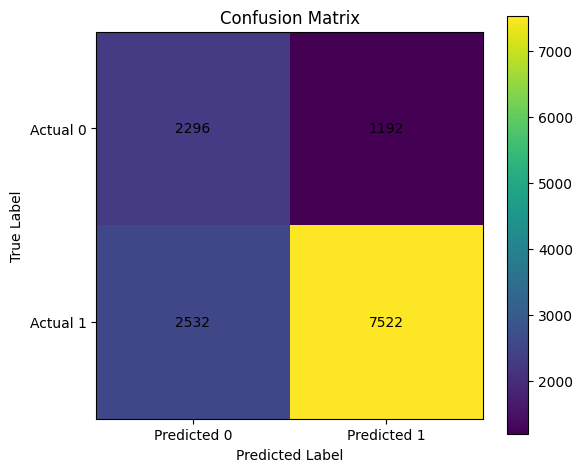

In [39]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

# -----------------------------
# Plot Confusion Matrix
# -----------------------------
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [42]:
torch.save({
    "model_state_dict": model.state_dict(),
    "best_threshold": best_thr
}, "20260203_Predictive_Model_NN_trained_full_data_health_claim_model.pt")

print("✅ Model + threshold saved successfully")


✅ Model + threshold saved successfully


# Test for Unseen data 

In [41]:
def predict_unseen_health(df, model_path, batch_size=32):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = HealthDataset(df)
    loader = DataLoader(dataset, batch_size=batch_size,
                        shuffle=False, collate_fn=health_collate_fn)

    model = HealthNN(emb_dim=64).to(device)

    ckpt = torch.load(model_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    threshold = ckpt["best_threshold"]

    model.eval()

    probs, preds = [], []

    with torch.no_grad():
        for batch in loader:
            logits = model(batch)
            p = torch.sigmoid(logits)
            probs.extend(p.cpu().numpy())
            preds.extend((p >= threshold).int().cpu().numpy())

    return probs, preds


In [ ]:
probs, preds = predict_unseen_health(
    df_unseen,
    model_path="model_with_threshold.pt"
)

df_unseen["probability"] = probs
df_unseen["prediction"] = preds


In [ ]:
"""import torch

MODEL_PATH = "20260203_Predictive_Model_NN_trained_full_data.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epochs": EPOCHS
}, MODEL_PATH)

print("✅ Model saved successfully:", MODEL_PATH)"""


✅ Model saved successfully: 20260203_Predictive_Model_NN_trained_full_data.pt
